In [4]:
pip install scipy

   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   -------- ------------------------------- 7.9/36.5 MB 49.1 MB/s eta 0:00:01
   ----------------------- ---------------- 21.8/36.5 MB 58.7 MB/s eta 0:00:01
   -------------------------------------- - 35.1/36.5 MB 60.8 MB/s eta 0:00:01
   ---------------------------------------- 36.5/36.5 MB 52.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mapclassify 2.10.0 requires networkx>=3.2, which is not installed.
mapclassify 2.10.0 requires scikit-learn>=1.4, which is not installed.
mlflow 3.12.0 requires aiohttp<4, which is not installed.
mlflow 3.12.0 requires alembic!=1.10.0,<2, which is not installed.
mlflow 3.12.0 requires cryptography<47,>=43.0.0, which is not installed.
mlflow 3.12.0 requires Flask<4, which is not installed.
mlflow 3.12.0 requires pyarrow<24,>=4.0.0, which is not installed.
mlflow 3.12.0 requires scikit-learn<2, which is not installed.
mlflow 3.12.0 requires sqlalchemy<3,>=1.4.0, which is not installed.
skops 0.14.0 requires scikit-learn>=1.2, which is not installed.
statsmodels 0.14.6 requires patsy>=0.5.6, which is not installed.
mlflow 3.12.0 requires pandas<3, but you have pandas 3.0.0 which is incompatible.

[notice] A new relea

In [5]:
import os
import scipy.io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import subprocess
import pandas as pd
import numpy as np

# 1. Point to your current directory (since your notebook is in 'data')
data_dir = "./" 

# 2. Read the descriptive names from dataset_names.txt
names_file_path = os.path.join(data_dir, "dataset_names.txt")

with open(names_file_path, "r") as f:
    dataset_names = [line.strip() for line in f.readlines() if line.strip()]

print(f"Loaded {len(dataset_names)} dataset names from text file.")

# 3. Loop through folders '1' to '62' and load the nested 'data.mat' files
all_datasets = {}

for i, name in enumerate(dataset_names):
    file_number = i + 1
    
    # Path format: ./1/data.mat, ./2/data.mat, etc.
    file_path = os.path.join(data_dir, str(file_number), "data.mat")
    
    if os.path.exists(file_path):
        try:
            # Load the MATLAB format file
            mat_data = scipy.io.loadmat(file_path)
            
            # Filter out MATLAB's internal metadata headers
            clean_data = {k: v for k, v in mat_data.items() if not k.startswith('__')}
            
            # Map it to its descriptive text name
            all_datasets[name] = clean_data
        except Exception as e:
            print(f"Could not load file from folder {file_number} ({name}): {e}")
    else:
        print(f"Warning: File '{file_path}' not found for dataset '{name}'")

print(f"\nSuccessfully loaded {len(all_datasets)} datasets into memory!")

Loaded 62 dataset names from text file.

Successfully loaded 62 datasets into memory!


In [6]:
# 1. Let's inspect the structural blueprint of the first 5 datasets
print(f"{'Dataset Name':<35} | {'Internal Keys (Variables)':<30} | {'Matrix Shape'}")
print("-" * 85)

# We loop through the first 5 to understand the pattern
for name in list(all_datasets.keys())[:5]:
    dataset_content = all_datasets[name]
    keys = list(dataset_content.keys())
    
    # Grab the shape of the first matrix variable found inside
    first_key = keys[0] if keys else None
    shape = dataset_content[first_key].shape if first_key is not None else "Empty"
    
    print(f"{name:<35} | {str(keys):<30} | {shape}")

print("-" * 85)

Dataset Name                        | Internal Keys (Variables)      | Matrix Shape
-------------------------------------------------------------------------------------
'breast-cancer-wisc-prog'           | ['X', 'y']                     | (198, 33)
'hepatitis'                         | ['X', 'y']                     | (155, 19)
'parkinsons'                        | ['X', 'y']                     | (195, 22)
'spectf'                            | ['X', 'y']                     | (267, 44)
'wine'                              | ['X', 'y']                     | (178, 13)
-------------------------------------------------------------------------------------


In [ ]:
import numpy as np
import pandas as pd

# 1. Initialize a list to hold the summary metrics for each dataset
summary_list = []

for name, dataset_content in all_datasets.items():
    # Flatten y to ensure it's a 1D array for easier element counting
    X = dataset_content['X']
    y = dataset_content['y'].flatten()
    
    total_samples = X.shape[0]
    num_features = X.shape[1]
    
    # Find unique labels and count how many there are
    unique_labels = np.unique(y)
    num_unique_labels = len(unique_labels)
    
    # Calculate counts and percentages for class 0 and class 1
    count_0 = np.sum(y == 0)
    count_1 = np.sum(y == 1)
    
    pct_0 = (count_0 / total_samples) * 100
    pct_1 = (count_1 / total_samples) * 100
    
    # Optional: Catch case where datasets use -1 and 1 instead of 0 and 1
    count_minus_1 = np.sum(y == -1)
    pct_minus_1 = (count_minus_1 / total_samples) * 100 if count_minus_1 > 0 else 0
    
    # Append all details to our list
    summary_list.append({
        "Dataset Name": name,
        "Total Samples": total_samples,
        "Features (X Columns)": num_features,
        "Unique Labels": list(unique_labels),
        "Total Unique": num_unique_labels,
        "% Class 0": f"{pct_0:.2f}%",
        "% Class 1": f"{pct_1:.2f}%",
        "% Class -1": f"{pct_minus_1:.2f}%" if count_minus_1 > 0 else "0.00%"
    })

# 2. Convert the summary list into a clean Pandas DataFrame
df_eda_summary = pd.DataFrame(summary_list)

# 3. Configure pandas to show all 62 rows without truncation in Jupyter
pd.set_option('display.max_rows', None)

# Display the summary table
df_eda_summary

,Dataset Name,Total Samples,Features (X Columns),Unique Labels,Total Unique,% Class 0,% Class 1,% Class -1
0,'breast-cancer-wisc-prog',198,33,"[0, 1]",2,76.26%,23.74%,0.00%
1,'hepatitis',155,19,"[0, 1]",2,20.65%,79.35%,0.00%
2,'parkinsons',195,22,"[0, 1]",2,24.62%,75.38%,0.00%
3,'spectf',267,44,"[0, 1]",2,20.60%,79.40%,0.00%
4,'wine',178,13,"[0, 1]",2,60.11%,39.89%,0.00%
5,'cervical-cancer',754,30,"[0, 1]",2,77.19%,22.81%,0.00%
6,'climate-model-simulation-crashes',678,18,"[0, 1]",2,27.14%,72.86%,0.00%
7,'colposcopies',287,62,"[0, 1]",2,24.74%,75.26%,0.00%
8,'glass-id',214,9,"[0, 1]",2,23.83%,76.17%,0.00%
9,'las-vegas-trip',503,31,"[0, 1]",2,55.07%,44.93%,0.00%


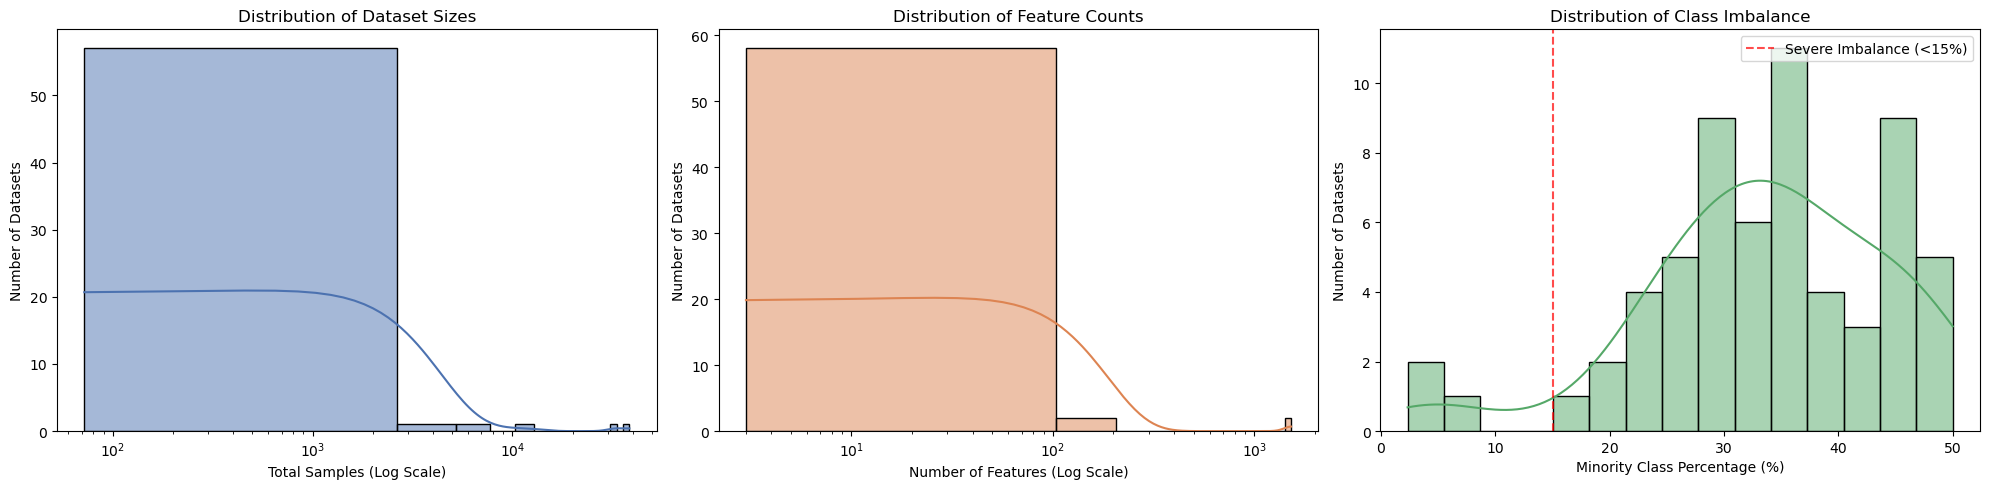

 🔍 MACHINE LEARNING PIPELINE INSIGHT DASHBOARD
Total Datasets Mapped: 62

🚨 1. SEVERELY IMBALANCED DATASETS (Minority < 15% - Need Resampling or PR-AUC/F1 Metrics):
  • 'the-mammography-dataset': Minority is only 2.32% (Labels: [np.int64(-1), np.int64(1)])
  • 'the-oil-dataset': Minority is only 4.38% (Labels: [np.int64(0), np.int64(1)])
  • 'the-forest-cover-dataset': Minority is only 7.13% (Labels: [np.int64(3), np.int64(4)])

📐 2. ULTRA HIGH-DIMENSIONAL DATASETS (Features > 100 - Need Feature Selection or Lasso/Ridge):
  • 'horse-colic-2': 108 features (with 300 samples)
  • 'cylinder-bands-2': 120 features (with 512 samples)
  • 'breast-cancer-wang': 1522 features (with 286 samples)
  • 'breast-cancer-nki': 1522 features (with 295 samples)

🐘 3. HEAVYWEIGHT DATASETS (Samples > 3,000 - Might need batch processing or faster models):
  • 'iranian-churn-dataset': 3150 samples
  • 'adult-dataset': 32561 samples
  • 'the-mammography-dataset': 11183 samples
  • 'phoneme-dataset': 5404 sam

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Build a robust summary DataFrame by dynamically handling all binary label formats
summary_list = []

for name, dataset_content in all_datasets.items():
    X = dataset_content['X']
    y = dataset_content['y'].flatten()
    
    total_samples = X.shape[0]
    num_features = X.shape[1]
    unique_labels = np.unique(y)
    
    # Calculate minority class percentage dynamically (works perfectly for [0,1], [-1,1], [1,2], [3,4], etc.)
    if len(unique_labels) == 2:
        count_a = np.sum(y == unique_labels[0])
        count_b = np.sum(y == unique_labels[1])
        minority_pct = (min(count_a, count_b) / total_samples) * 100
    else:
        minority_pct = np.nan
        
    summary_list.append({
        "Dataset Name": name,
        "Total Samples": total_samples,
        "Features": num_features,
        "Minority %": minority_pct,
        "Labels": list(unique_labels)
    })

df_summary = pd.DataFrame(summary_list)

# 2. Generate Visual Distribution Charts
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot 1: Dataset Sizes
sns.histplot(df_summary['Total Samples'], bins=15, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_xscale('log')
axes[0].set_title('Distribution of Dataset Sizes')
axes[0].set_xlabel('Total Samples (Log Scale)')
axes[0].set_ylabel('Number of Datasets')

# Plot 2: Feature Counts
sns.histplot(df_summary['Features'], bins=15, kde=True, ax=axes[1], color='#DD8452')
axes[1].set_xscale('log')
axes[1].set_title('Distribution of Feature Counts')
axes[1].set_xlabel('Number of Features (Log Scale)')
axes[1].set_ylabel('Number of Datasets')

# Plot 3: Class Imbalance Distribution
sns.histplot(df_summary['Minority %'], bins=15, kde=True, ax=axes[2], color='#55A868')
axes[2].set_title('Distribution of Class Imbalance')
axes[2].set_xlabel('Minority Class Percentage (%)')
axes[2].set_ylabel('Number of Datasets')
axes[2].axvline(15, color='red', linestyle='--', alpha=0.7, label='Severe Imbalance (<15%)')
axes[2].legend()

plt.tight_layout()
plt.show()

# 3. Print out the "ML Strategy Alerts"
print("="*70)
print(" 🔍 MACHINE LEARNING PIPELINE INSIGHT DASHBOARD")
print("="*70)
print(f"Total Datasets Mapped: {len(df_summary)}")

print("\n🚨 1. SEVERELY IMBALANCED DATASETS (Minority < 15% - Need Resampling or PR-AUC/F1 Metrics):")
severe_imb = df_summary[df_summary['Minority %'] < 15]
if not severe_imb.empty:
    for _, row in severe_imb.iterrows():
        print(f"  • {row['Dataset Name']}: Minority is only {row['Minority %']:.2f}% (Labels: {row['Labels']})")
else:
    print("  • None! All datasets are reasonably balanced.")

print("\n📐 2. ULTRA HIGH-DIMENSIONAL DATASETS (Features > 100 - Need Feature Selection or Lasso/Ridge):")
high_dim = df_summary[df_summary['Features'] > 100]
if not high_dim.empty:
    for _, row in high_dim.iterrows():
        print(f"  • {row['Dataset Name']}: {row['Features']} features (with {row['Total Samples']} samples)")
else:
    print("  • None!")

print("\n🐘 3. HEAVYWEIGHT DATASETS (Samples > 3,000 - Might need batch processing or faster models):")
large_data = df_summary[df_summary['Total Samples'] > 3000]
if not large_data.empty:
    for _, row in large_data.iterrows():
        print(f"  • {row['Dataset Name']}: {row['Total Samples']} samples")
else:
    print("  • None!")

In [ ]:
import pickle

# Define the output file name
pickle_file_path = "./all_datasets.pkl"

# Save the 'all_datasets' dictionary to disk
with open(pickle_file_path, "wb") as f:
    pickle.dump(all_datasets, f)

print(f"🎉 Success! All 62 datasets saved into '{pickle_file_path}'")

🎉 Success! All 62 datasets saved into './all_datasets.pkl'


In [ ]:
import numpy as np
import pandas as pd

# 1. Gather raw numbers from all 62 datasets
dataset_stats = []

for name, dataset_content in all_datasets.items():
    X = dataset_content['X']
    y = dataset_content['y'].flatten()
    
    total_samples = X.shape[0]
    num_features = X.shape[1]
    unique_labels = np.unique(y)
    
    # Dynamically find minority class percentage
    if len(unique_labels) == 2:
        count_a = np.sum(y == unique_labels[0])
        count_b = np.sum(y == unique_labels[1])
        minority_pct = (min(count_a, count_b) / total_samples) * 100
    else:
        minority_pct = np.nan
        
    dataset_stats.append({
        "samples": total_samples,
        "features": num_features,
        "minority_pct": minority_pct
    })

df_stats = pd.DataFrame(dataset_stats)
total_datasets = len(df_stats)

print("=" * 65)
print(" 📊 METRICS DISTRIBUTION REPORT (GLOBAL COLLECTION ANALYSIS)")
print("=" * 65)

# --- 1. FEATURE COLUMN INSIGHTS ---
print("\n📐 FEATURE COUNT DISTRIBUTION:")
feat_less_10 = (df_stats['features'] <= 10).sum() / total_datasets * 100
feat_less_20 = (df_stats['features'] <= 20).sum() / total_datasets * 100
feat_less_50 = (df_stats['features'] <= 50).sum() / total_datasets * 100
feat_over_100 = (df_stats['features'] > 100).sum() / total_datasets * 100

print(f" • {feat_less_10:.1f}% of your datasets have 10 features or fewer.")
print(f" • {feat_less_20:.1f}% of your datasets have 20 features or fewer.")
print(f" • {feat_less_50:.1f}% of your datasets have 50 features or fewer.")
print(f" • Only {feat_over_100:.1f}% are high-dimensional outliers (over 100 features).")

# --- 2. SAMPLE SIZE (ROW) INSIGHTS ---
print("\n🐘 DATASET SIZE (ROWS) DISTRIBUTION:")
rows_less_300 = (df_stats['samples'] <= 300).sum() / total_datasets * 100
rows_less_500 = (df_stats['samples'] <= 500).sum() / total_datasets * 100
rows_less_1000 = (df_stats['samples'] <= 1000).sum() / total_datasets * 100
rows_over_3000 = (df_stats['samples'] > 3000).sum() / total_datasets * 100

print(f" • {rows_less_300:.1f}% of your datasets are small, having 300 rows or fewer.")
print(f" • {rows_less_500:.1f}% of your datasets have 500 rows or fewer.")
print(f" • {rows_less_1000:.1f}% of your datasets have 1,000 rows or fewer.")
print(f" • Only {rows_over_3000:.1f}% are heavy-weight datasets (over 3,000 rows).")

# --- 3. CLASS IMBALANCE (ANOMALY DETECT) INSIGHTS ---
print("\n🚨 CLASS IMBALANCE (ANOMALY) REGION:")
severe_anomaly = (df_stats['minority_pct'] <= 5).sum() / total_datasets * 100
moderate_imb = ((df_stats['minority_pct'] > 5) & (df_stats['minority_pct'] <= 20)).sum() / total_datasets * 100
perfect_balance = (df_stats['minority_pct'] > 40).sum() / total_datasets * 100

print(f" • {severe_anomaly:.1f}% of your datasets live in the 'Extreme Anomaly Zone' (Minority Class ≤ 5%).")
print(f" • {moderate_imb:.1f}% have moderate imbalance (Minority between 5% and 20%).")
print(f" • {perfect_balance:.1f}% are near-perfectly split/balanced (Minority Class > 40%).")

# --- 4. EXACT STATISTICAL QUANTILES ---
print("\n📊 EXACT DATASET QUANTILES (Percentiles):")
print(df_stats.describe(percentiles=[0.25, 0.5, 0.75, 0.90]).round(1))
print("=" * 65)

 📊 METRICS DISTRIBUTION REPORT (GLOBAL COLLECTION ANALYSIS)

📐 FEATURE COUNT DISTRIBUTION:
 • 38.7% of your datasets have 10 features or fewer.
 • 54.8% of your datasets have 20 features or fewer.
 • 85.5% of your datasets have 50 features or fewer.
 • Only 6.5% are high-dimensional outliers (over 100 features).

🐘 DATASET SIZE (ROWS) DISTRIBUTION:
 • 45.2% of your datasets are small, having 300 rows or fewer.
 • 54.8% of your datasets have 500 rows or fewer.
 • 87.1% of your datasets have 1,000 rows or fewer.
 • Only 8.1% are heavy-weight datasets (over 3,000 rows).

🚨 CLASS IMBALANCE (ANOMALY) REGION:
 • 3.2% of your datasets live in the 'Extreme Anomaly Zone' (Minority Class ≤ 5%).
 • 3.2% have moderate imbalance (Minority between 5% and 20%).
 • 27.4% are near-perfectly split/balanced (Minority Class > 40%).

📊 EXACT DATASET QUANTILES (Percentiles):
       samples  features  minority_pct
count     62.0      62.0          62.0
mean    1893.7      74.8          33.6
std     6405.1   

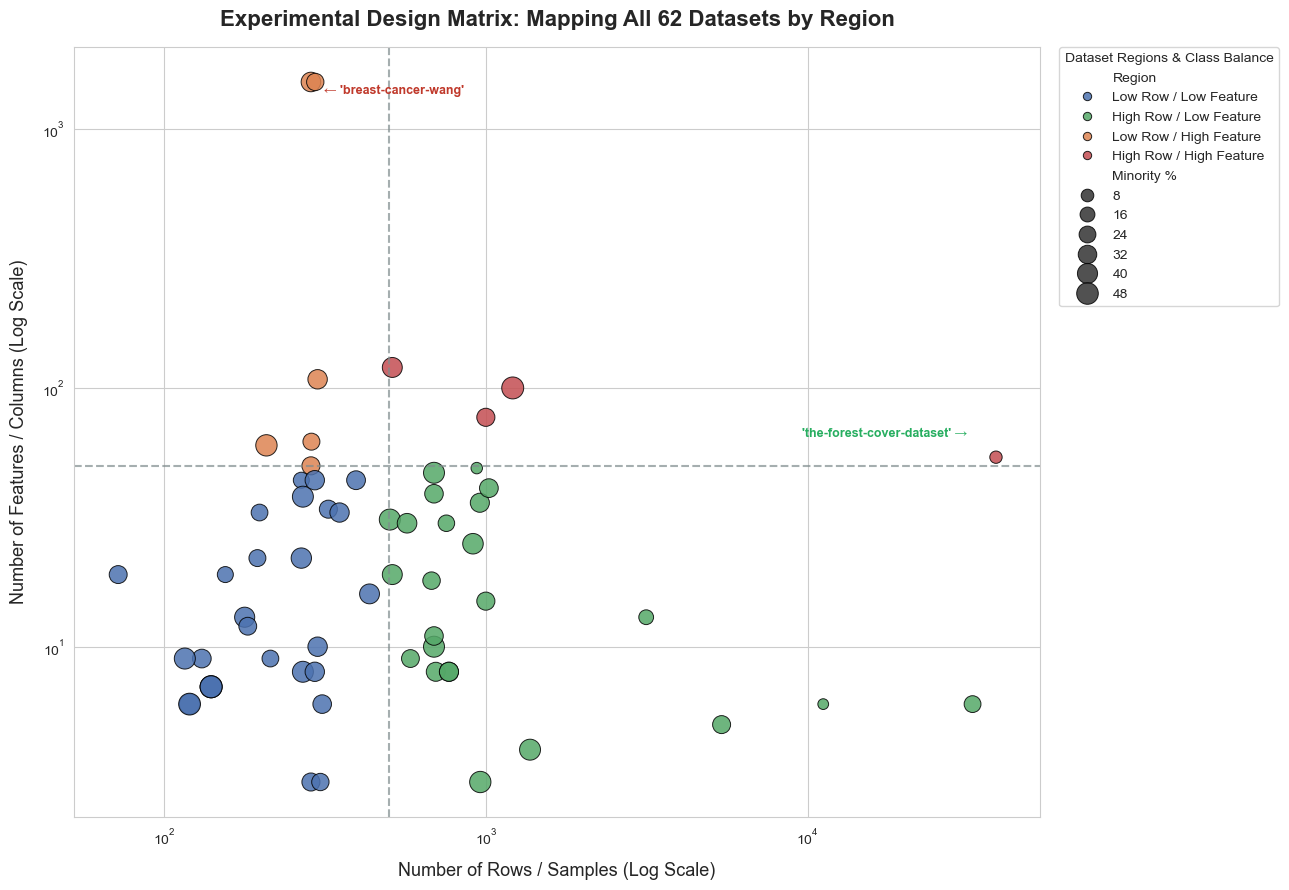

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Process the dictionary into a plotting DataFrame
plot_data = []
for name, dataset_content in all_datasets.items():
    X = dataset_content['X']
    y = dataset_content['y'].flatten()
    
    total_samples = X.shape[0]
    num_features = X.shape[1]
    
    # Categorize into 4 structural regions based on thresholds
    row_kind = "Low Row" if total_samples < 500 else "High Row"
    feat_kind = "Low Feature" if num_features < 50 else "High Feature"
    region = f"{row_kind} / {feat_kind}"
    
    # Extract class imbalance to control point sizes
    unique_labels = np.unique(y)
    if len(unique_labels) == 2:
        count_a = np.sum(y == unique_labels[0])
        count_b = np.sum(y == unique_labels[1])
        minority_pct = (min(count_a, count_b) / total_samples) * 100
    else:
        minority_pct = 50.0  # Default fallback

    plot_data.append({
        "Dataset Name": name,
        "Rows": total_samples,
        "Features": num_features,
        "Region": region,
        "Minority %": minority_pct
    })

df_plot = pd.DataFrame(plot_data)

# 2. Set up the plotting environment
plt.figure(figsize=(13, 9))
sns.set_style("whitegrid")

# Define contrasting, professional color mappings for the regions
palette = {
    "Low Row / Low Feature": "#4C72B0",   # Muted Blue
    "Low Row / High Feature": "#DD8452",  # Muted Orange
    "High Row / Low Feature": "#55A868",  # Muted Green
    "High Row / High Feature": "#C44E52"  # Muted Red
}

# 3. Generate the Scatter Plot
# Note: Size represents how balanced the dataset is (Larger point = More balanced)
ax = sns.scatterplot(
    data=df_plot,
    x="Rows",
    y="Features",
    hue="Region",
    palette=palette,
    size="Minority %",
    sizes=(60, 250),
    alpha=0.85,
    edgecolor="black",
    linewidth=0.7
)

# 4. Draw Quadrant Split Lines (Thresholds: 500 Rows, 50 Features)
plt.axvline(x=500, color="#7f8c8d", linestyle="--", alpha=0.7, linewidth=1.5)
plt.axhline(y=50, color="#7f8c8d", linestyle="--", alpha=0.7, linewidth=1.5)

# 5. Apply Logarithmic Scales to elegantly handle the massive scaling range
plt.xscale('log')
plt.yscale('log')

# 6. Dynamically annotate the most extreme outliers so you can orient yourself
top_features = df_plot.loc[df_plot['Features'].idxmax()]
top_rows = df_plot.loc[df_plot['Rows'].idxmax()]

plt.text(top_features['Rows'] * 1.1, top_features['Features'] * 0.9, f"← {top_features['Dataset Name']}", 
         fontsize=9, fontweight='bold', color='#c0392b')
plt.text(top_rows['Rows'] * 0.25, top_rows['Features'] * 1.2, f"{top_rows['Dataset Name']} →", 
         fontsize=9, fontweight='bold', color='#27ae60')

# 7. Labels, Legends, and Titles
plt.title("Experimental Design Matrix: Mapping All 62 Datasets by Region", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Number of Rows / Samples (Log Scale)", fontsize=13, labelpad=10)
plt.ylabel("Number of Features / Columns (Log Scale)", fontsize=13, labelpad=10)

# Move legend completely outside the plot area so it doesn't cover data points
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title="Dataset Regions & Class Balance")

plt.tight_layout()
plt.show()

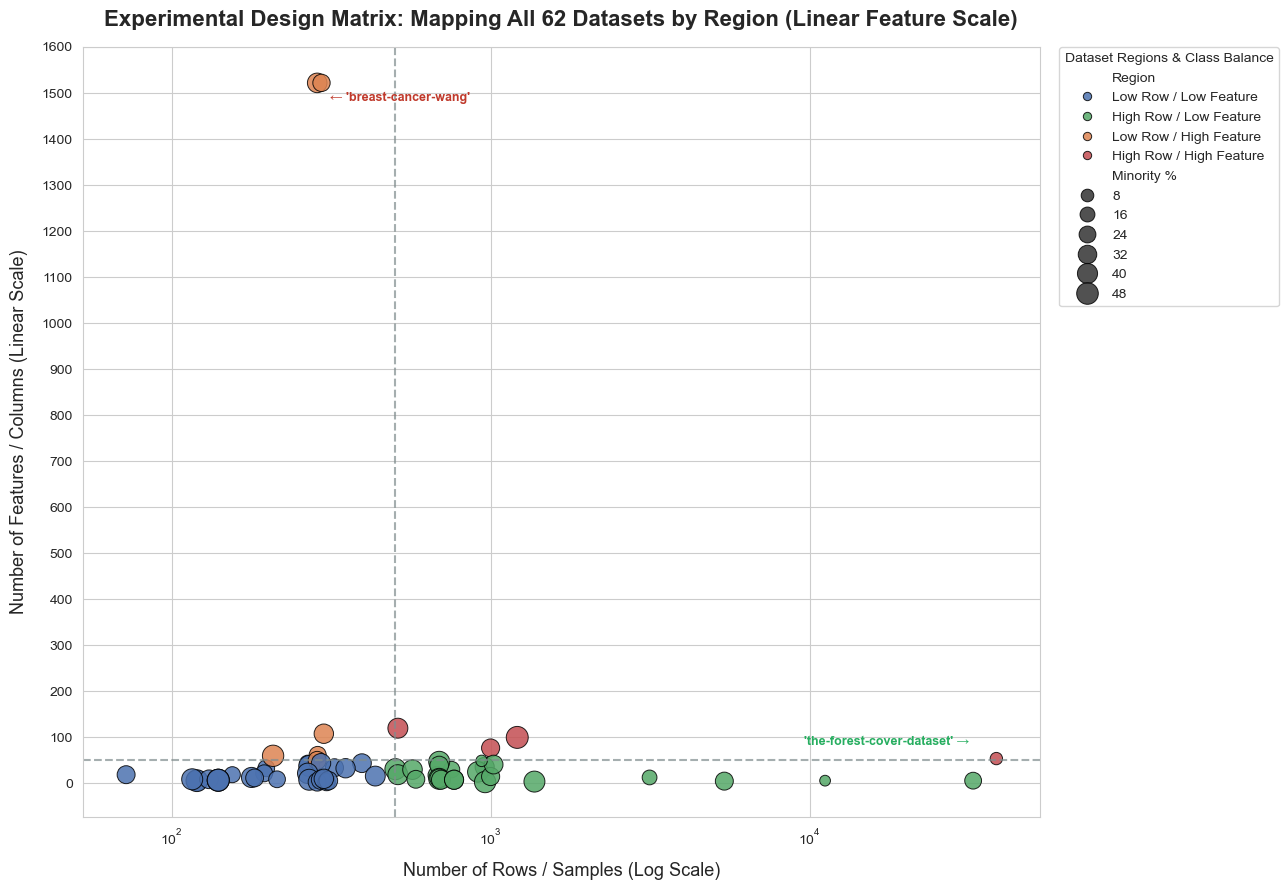

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Process the dictionary into a plotting DataFrame
plot_data = []
for name, dataset_content in all_datasets.items():
    X = dataset_content['X']
    y = dataset_content['y'].flatten()
    
    total_samples = X.shape[0]
    num_features = X.shape[1]
    
    # Categorize into 4 structural regions based on thresholds
    row_kind = "Low Row" if total_samples < 500 else "High Row"
    feat_kind = "Low Feature" if num_features < 50 else "High Feature"
    region = f"{row_kind} / {feat_kind}"
    
    # Extract class imbalance to control point sizes
    unique_labels = np.unique(y)
    if len(unique_labels) == 2:
        count_a = np.sum(y == unique_labels[0])
        count_b = np.sum(y == unique_labels[1])
        minority_pct = (min(count_a, count_b) / total_samples) * 100
    else:
        minority_pct = 50.0  # Default fallback

    plot_data.append({
        "Dataset Name": name,
        "Rows": total_samples,
        "Features": num_features,
        "Region": region,
        "Minority %": minority_pct
    })

df_plot = pd.DataFrame(plot_data)

# 2. Set up the plotting environment
plt.figure(figsize=(13, 9))
sns.set_style("whitegrid")

# Define contrasting, professional color mappings for the regions
palette = {
    "Low Row / Low Feature": "#4C72B0",   # Muted Blue
    "Low Row / High Feature": "#DD8452",  # Muted Orange
    "High Row / Low Feature": "#55A868",  # Muted Green
    "High Row / High Feature": "#C44E52"  # Muted Red
}

# 3. Generate the Scatter Plot
ax = sns.scatterplot(
    data=df_plot,
    x="Rows",
    y="Features",
    hue="Region",
    palette=palette,
    size="Minority %",
    sizes=(60, 250),
    alpha=0.85,
    edgecolor="black",
    linewidth=0.7
)

# 4. Draw Quadrant Split Lines (Thresholds: 500 Rows, 50 Features)
plt.axvline(x=500, color="#7f8c8d", linestyle="--", alpha=0.7, linewidth=1.5)
plt.axhline(y=50, color="#7f8c8d", linestyle="--", alpha=0.7, linewidth=1.5)

# 5. Apply Logarithmic Scale ONLY to the X-Axis (Rows)
plt.xscale('log')
# Y-Axis (Features) is now standard LINEAR scale!

# 6. Dynamically annotate the most extreme outliers
top_features = df_plot.loc[df_plot['Features'].idxmax()]
top_rows = df_plot.loc[df_plot['Rows'].idxmax()]

# Adjusted text positioning to look clean on the new linear Y scale
plt.text(top_features['Rows'] * 1.1, top_features['Features'] - 40, f"← {top_features['Dataset Name']}", 
         fontsize=9, fontweight='bold', color='#c0392b')
plt.text(top_rows['Rows'] * 0.25, top_rows['Features'] + 30, f"{top_rows['Dataset Name']} →", 
         fontsize=9, fontweight='bold', color='#27ae60')

# Set y-axis ticks to show clean increments up to your maximum feature count
plt.yticks(np.arange(0, 1700, 100))

# 7. Labels, Legends, and Titles
plt.title("Experimental Design Matrix: Mapping All 62 Datasets by Region (Linear Feature Scale)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Number of Rows / Samples (Log Scale)", fontsize=13, labelpad=10)
plt.ylabel("Number of Features / Columns (Linear Scale)", fontsize=13, labelpad=10)

# Move legend completely outside the plot area
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title="Dataset Regions & Class Balance")

plt.tight_layout()
plt.show()

IndexError: single positional indexer is out-of-bounds

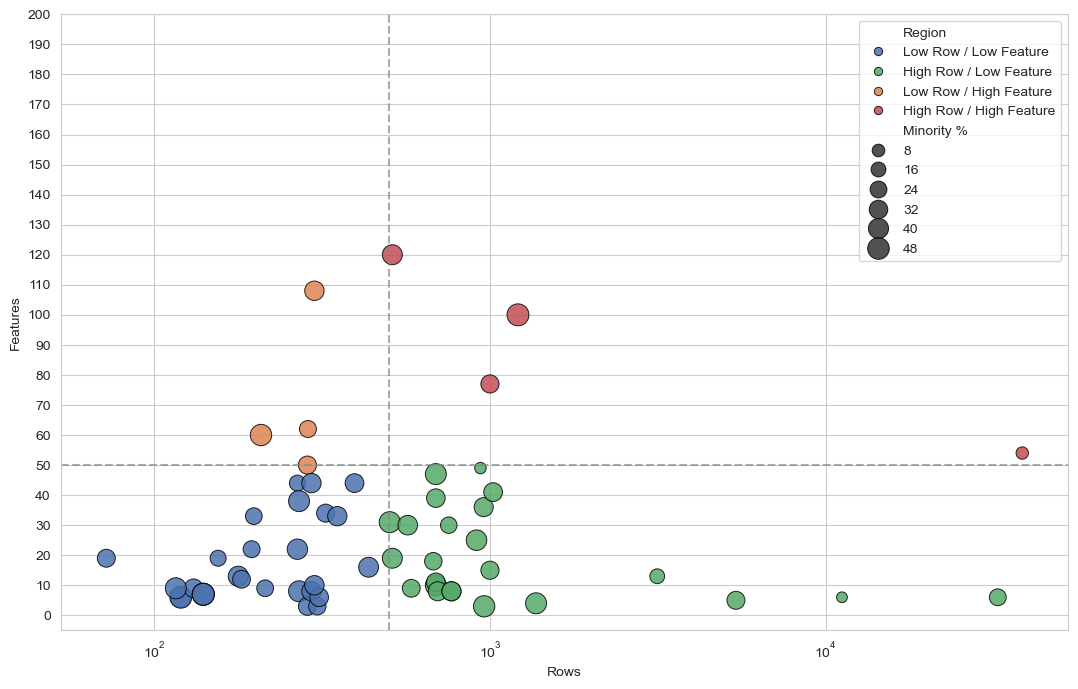

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Process the dictionary into a plotting DataFrame
plot_data = []
for name, dataset_content in all_datasets.items():
    X = dataset_content['X']
    y = dataset_content['y'].flatten()
    
    total_samples = X.shape[0]
    num_features = X.shape[1]
    
    # Categorize into 4 structural regions based on thresholds
    row_kind = "Low Row" if total_samples < 500 else "High Row"
    feat_kind = "Low Feature" if num_features < 50 else "High Feature"
    region = f"{row_kind} / {feat_kind}"
    
    # Extract class imbalance to control point sizes
    unique_labels = np.unique(y)
    if len(unique_labels) == 2:
        count_a = np.sum(y == unique_labels[0])
        count_b = np.sum(y == unique_labels[1])
        minority_pct = (min(count_a, count_b) / total_samples) * 100
    else:
        minority_pct = 50.0  # Default fallback

    plot_data.append({
        "Dataset Name": name,
        "Rows": total_samples,
        "Features": num_features,
        "Region": region,
        "Minority %": minority_pct
    })

df_plot = pd.DataFrame(plot_data)

# 2. Set up the plotting environment
plt.figure(figsize=(13, 8))
sns.set_style("whitegrid")

palette = {
    "Low Row / Low Feature": "#4C72B0",   # Muted Blue
    "Low Row / High Feature": "#DD8452",  # Muted Orange
    "High Row / Low Feature": "#55A868",  # Muted Green
    "High Row / High Feature": "#C44E52"  # Muted Red
}

# 3. Generate the Scatter Plot
ax = sns.scatterplot(
    data=df_plot,
    x="Rows",
    y="Features",
    hue="Region",
    palette=palette,
    size="Minority %",
    sizes=(60, 250),
    alpha=0.85,
    edgecolor="black",
    linewidth=0.7
)

# 4. Draw Quadrant Split Lines (Thresholds: 500 Rows, 50 Features)
plt.axvline(x=500, color="#7f8c8d", linestyle="--", alpha=0.7, linewidth=1.5)
plt.axhline(y=50, color="#7f8c8d", linestyle="--", alpha=0.7, linewidth=1.5)

# 5. Apply Logarithmic Scale ONLY to X-Axis (Rows)
plt.xscale('log')

# 6. ZOOM IN: Explicitly limit the Y-axis to focus on features below 200
plt.ylim(-5, 200)
plt.yticks(np.arange(0, 210, 10))  # Show gridlines every 10 features for perfect readability

# 7. Annotate key datasets that are visible in this zoomed range
# Let's label the highest feature dataset *under* 200 features, and the forest cover dataset
df_sub_200 = df_plot[df_plot['Features'] < 200]
top_zoomed_feat = df_sub_200.loc[df_sub_200['Features'].idxmax()]
forest_dataset = df_plot[df_plot['Dataset Name'] == 'the-forest-cover-dataset'].iloc[0]

plt.text(top_zoomed_feat['Rows'] * 1.1, top_zoomed_feat['Features'], f"← {top_zoomed_feat['Dataset Name']}", 
         fontsize=9, fontweight='bold', color='#d35400')
plt.text(forest_dataset['Rows'] * 0.2, forest_dataset['Features'] + 5, f"{forest_dataset['Dataset Name']} →", 
         fontsize=9, fontweight='bold', color='#27ae60')

# 8. Labels, Legends, and Titles
plt.title("Experimental Design Matrix: Zoomed-In View (Features < 200)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Number of Rows / Samples (Log Scale)", fontsize=13, labelpad=10)
plt.ylabel("Number of Features / Columns (Linear Scale: 0 to 200)", fontsize=13, labelpad=10)

# Position legend cleanly outside
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title="Dataset Regions & Class Balance")

plt.tight_layout()
plt.show()

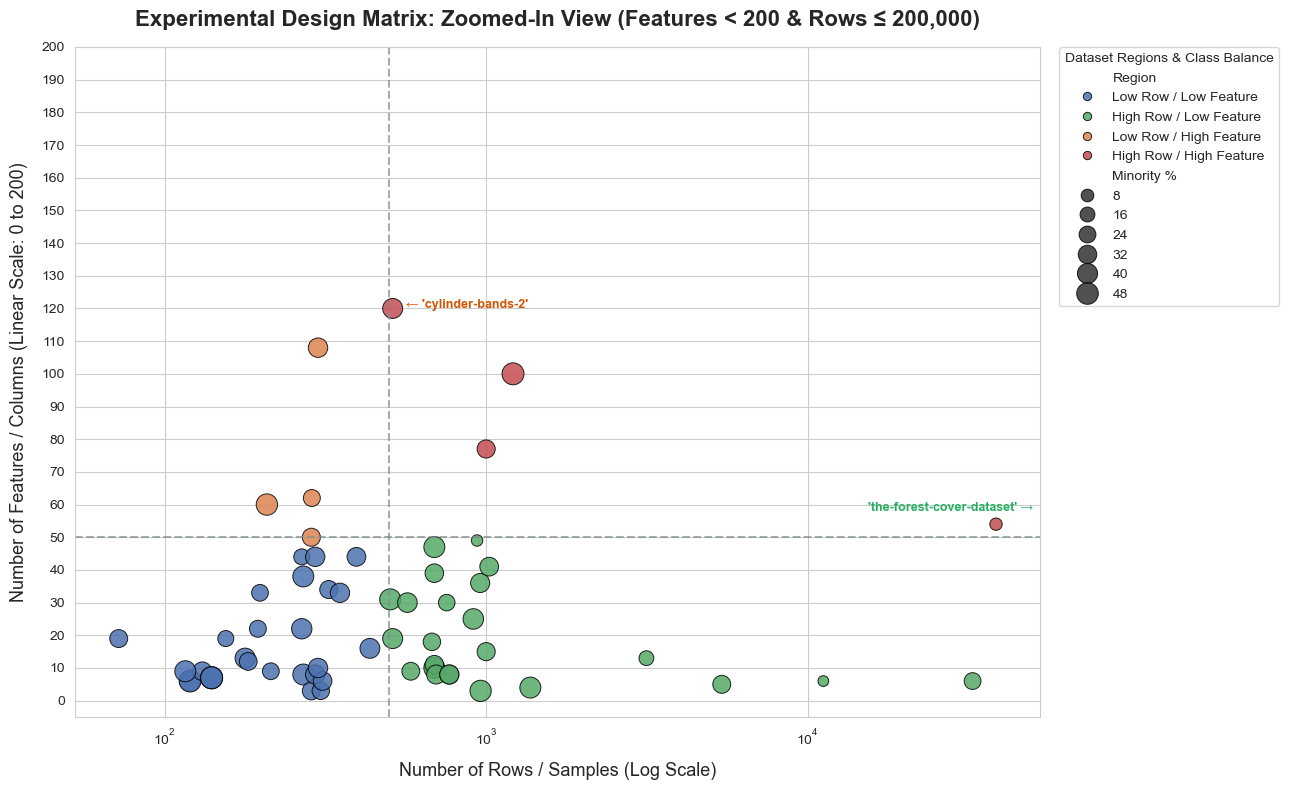

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Process the dictionary into a master dataframe
plot_data = []
for name, dataset_content in all_datasets.items():
    X = dataset_content['X']
    y = dataset_content['y'].flatten()
    
    total_samples = X.shape[0]
    num_features = X.shape[1]
    
    # Categorize into 4 structural regions based on baseline thresholds
    row_kind = "Low Row" if total_samples < 500 else "High Row"
    feat_kind = "Low Feature" if num_features < 50 else "High Feature"
    region = f"{row_kind} / {feat_kind}"
    
    # Extract class imbalance to control point sizes
    unique_labels = np.unique(y)
    if len(unique_labels) == 2:
        count_a = np.sum(y == unique_labels[0])
        count_b = np.sum(y == unique_labels[1])
        minority_pct = (min(count_a, count_b) / total_samples) * 100
    else:
        minority_pct = 50.0  # Default fallback

    plot_data.append({
        "Dataset Name": name,
        "Rows": total_samples,
        "Features": num_features,
        "Region": region,
        "Minority %": minority_pct
    })

df_master = pd.DataFrame(plot_data)

# 2. APPLY YOUR FILTERS: Features < 200 AND Rows <= 200,000
df_filtered = df_master[(df_master['Features'] < 200) & (df_master['Rows'] <= 200000)].copy()

# 3. Set up the plotting environment
plt.figure(figsize=(13, 8))
sns.set_style("whitegrid")

palette = {
    "Low Row / Low Feature": "#4C72B0",   # Muted Blue
    "Low Row / High Feature": "#DD8452",  # Muted Orange
    "High Row / Low Feature": "#55A868",  # Muted Green
    "High Row / High Feature": "#C44E52"  # Muted Red
}

# 4. Generate the Scatter Plot using our safely filtered data
ax = sns.scatterplot(
    data=df_filtered,
    x="Rows",
    y="Features",
    hue="Region",
    palette=palette,
    size="Minority %",
    sizes=(60, 250),
    alpha=0.85,
    edgecolor="black",
    linewidth=0.7
)

# 5. Draw Quadrant Split Lines (Thresholds: 500 Rows, 50 Features)
plt.axvline(x=500, color="#7f8c8d", linestyle="--", alpha=0.7, linewidth=1.5)
plt.axhline(y=50, color="#7f8c8d", linestyle="--", alpha=0.7, linewidth=1.5)

# 6. Apply Logarithmic Scale to X-Axis (Rows)
plt.xscale('log')

# 7. Set clean bounds on the axes based on your filter limits
plt.ylim(-5, 200)
plt.yticks(np.arange(0, 210, 10))  # Gridlines every 10 features

# 8. SAFE DYNAMIC ANNOTATIONS (No hardcoded names to prevent crashes)
if not df_filtered.empty:
    # Dynamically find the dataset with the highest features in this view
    top_features = df_filtered.loc[df_filtered['Features'].idxmax()]
    plt.text(top_features['Rows'] * 1.1, top_features['Features'], f"← {top_features['Dataset Name']}", 
             fontsize=9, fontweight='bold', color='#d35400')
    
    # Dynamically find the dataset with the highest number of rows in this view
    top_rows = df_filtered.loc[df_filtered['Rows'].idxmax()]
    plt.text(top_rows['Rows'] * 0.4, top_rows['Features'] + 4, f"{top_rows['Dataset Name']} →", 
             fontsize=9, fontweight='bold', color='#27ae60')

# 9. Labels, Legends, and Titles
plt.title("Experimental Design Matrix: Zoomed-In View (Features < 200 & Rows ≤ 200,000)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Number of Rows / Samples (Log Scale)", fontsize=13, labelpad=10)
plt.ylabel("Number of Features / Columns (Linear Scale: 0 to 200)", fontsize=13, labelpad=10)

# Position legend cleanly outside
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title="Dataset Regions & Class Balance")

plt.tight_layout()
plt.show()

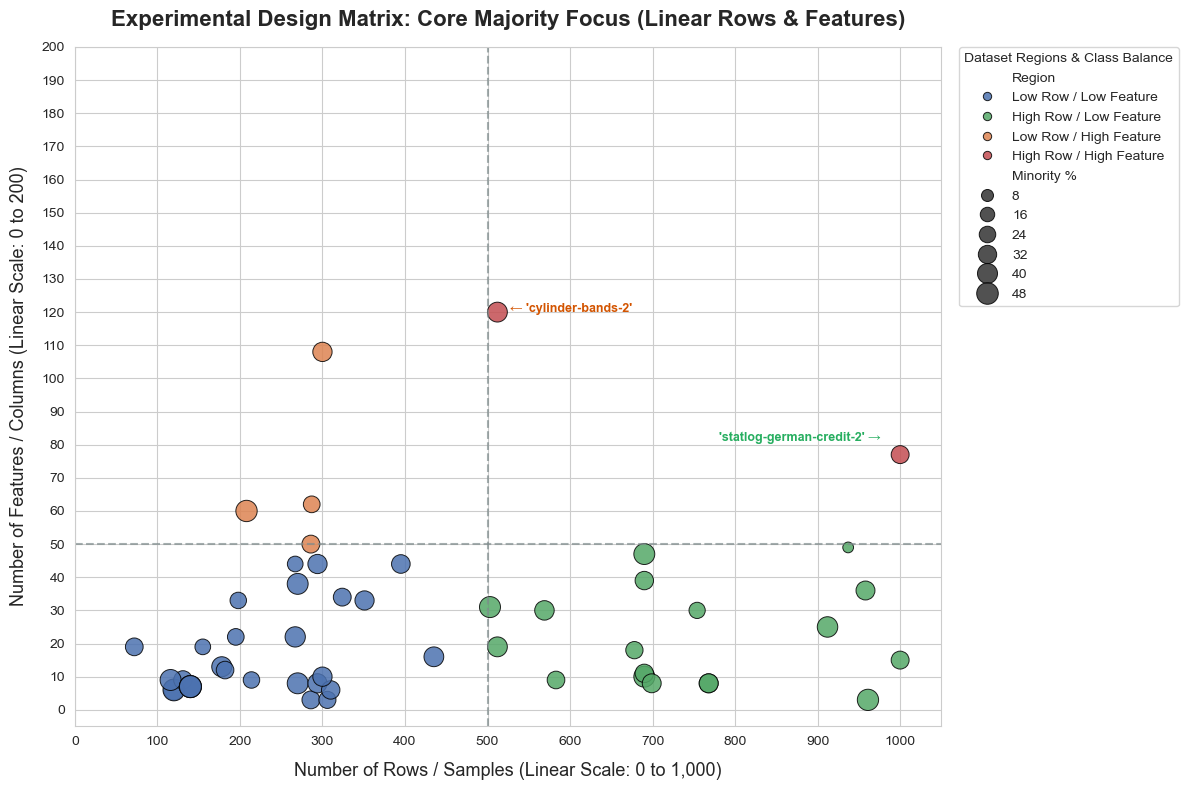

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Process the dictionary into a master dataframe
plot_data = []
for name, dataset_content in all_datasets.items():
    X = dataset_content['X']
    y = dataset_content['y'].flatten()
    
    total_samples = X.shape[0]
    num_features = X.shape[1]
    
    row_kind = "Low Row" if total_samples < 500 else "High Row"
    feat_kind = "Low Feature" if num_features < 50 else "High Feature"
    region = f"{row_kind} / {feat_kind}"
    
    unique_labels = np.unique(y)
    if len(unique_labels) == 2:
        count_a = np.sum(y == unique_labels[0])
        count_b = np.sum(y == unique_labels[1])
        minority_pct = (min(count_a, count_b) / total_samples) * 100
    else:
        minority_pct = 50.0

    plot_data.append({
        "Dataset Name": name,
        "Rows": total_samples,
        "Features": num_features,
        "Region": region,
        "Minority %": minority_pct
    })

df_master = pd.DataFrame(plot_data)

# 2. APPLY YOUR NEW FILTERS: Focus purely on the core majority group
# Features < 200 AND Rows <= 1000 (Excluding the 5 long-row outliers)
df_filtered = df_master[(df_master['Features'] < 200) & (df_master['Rows'] <= 1000)].copy()

# 3. Set up the plotting environment
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

palette = {
    "Low Row / Low Feature": "#4C72B0",
    "Low Row / High Feature": "#DD8452",
    "High Row / Low Feature": "#55A868",
    "High Row / High Feature": "#C44E52"
}

# 4. Generate the True Linear Scatter Plot
ax = sns.scatterplot(
    data=df_filtered,
    x="Rows",
    y="Features",
    hue="Region",
    palette=palette,
    size="Minority %",
    sizes=(60, 250),
    alpha=0.85,
    edgecolor="black",
    linewidth=0.7
)

# 5. Draw Quadrant Split Lines (Thresholds: 500 Rows, 50 Features)
plt.axvline(x=500, color="#7f8c8d", linestyle="--", alpha=0.7, linewidth=1.5)
plt.axhline(y=50, color="#7f8c8d", linestyle="--", alpha=0.7, linewidth=1.5)

# --- BOTH AXES ARE NOW STANDARD LINEAR SCALES ---
plt.xlim(0, 1050)
plt.xticks(np.arange(0, 1100, 100)) # Marks every 100 rows clearly

plt.ylim(-5, 200)
plt.yticks(np.arange(0, 210, 10))   # Marks every 10 features clearly

# 6. SAFE DYNAMIC ANNOTATIONS FOR THE NEW CORE VIEW
if not df_filtered.empty:
    # Label the highest feature dataset in this zoomed-in group
    top_features = df_filtered.loc[df_filtered['Features'].idxmax()]
    plt.text(top_features['Rows'] + 15, top_features['Features'], f"← {top_features['Dataset Name']}", 
             fontsize=9, fontweight='bold', color='#d35400')
    
    # Label the highest row dataset in this zoomed-in group
    top_rows = df_filtered.loc[df_filtered['Rows'].idxmax()]
    plt.text(top_rows['Rows'] - 220, top_rows['Features'] + 4, f"{top_rows['Dataset Name']} →", 
             fontsize=9, fontweight='bold', color='#27ae60')

# 7. Labels, Legends, and Titles
plt.title("Experimental Design Matrix: Core Majority Focus (Linear Rows & Features)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Number of Rows / Samples (Linear Scale: 0 to 1,000)", fontsize=13, labelpad=10)
plt.ylabel("Number of Features / Columns (Linear Scale: 0 to 200)", fontsize=13, labelpad=10)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title="Dataset Regions & Class Balance")

plt.tight_layout()
plt.savefig('experimental_design_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import numpy as np
import pandas as pd

# We will test on a subset of 10 datasets first to see the performance trends
test_datasets = list(all_datasets.keys())[:10]

results = []

for name in test_datasets:
    X = all_datasets[name]['X']
    y = all_datasets[name]['y'].flatten()
    
    # Check for and fix any non-standard labels (e.g., [1, 2] or [3, 4]) to [0, 1]
    unique_labels = np.unique(y)
    if not np.array_equal(unique_labels, [0, 1]):
        y = np.where(y == unique_labels[0], 0, 1)
        
    # Scale features (Required for SVM and Logistic Regression)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Initialize our three target models
    models = {
        "Logistic Regression": LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
        "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
        "SVM (RBF Kernel)": SVC(class_weight='balanced', random_state=42)
    }
    
    dataset_scores = {"Dataset": name}
    
    for model_name, model in models.items():
        # Using ROC-AUC because it accounts for the class imbalances you found in your EDA
        scores = cross_val_score(model, X_scaled, y, cv=3, scoring='roc_auc')
        dataset_scores[model_name] = round(scores.mean(), 4)
        
    results.append(dataset_scores)

# Convert results to a clean DataFrame to see the winner
df_results = pd.DataFrame(results)
df_results

,Dataset,Logistic Regression,Random Forest,SVM (RBF Kernel)
0,'breast-cancer-wisc-prog',0.8101,0.6988,0.7300
1,'hepatitis',0.8228,0.8715,0.8669
2,'parkinsons',0.8576,0.8869,0.8963
3,'spectf',0.8820,0.8813,0.8325
4,'wine',0.9899,0.9947,0.9915
5,'cervical-cancer',0.6365,0.8714,0.7151
6,'climate-model-simulation-crashes',0.9643,0.9999,0.9997
7,'colposcopies',0.7135,0.6989,0.6754
8,'glass-id',0.9067,0.9662,0.9782
9,'las-vegas-trip',0.5485,0.5002,0.5233


In [ ]:
import numpy as np
import pandas as pd

balance_summary = []

for name, dataset_content in all_datasets.items():
    X = dataset_content['X']
    y = dataset_content['y'].flatten()
    
    total_samples = X.shape[0]
    num_features = X.shape[1]
    
    # Apply your exact visual majority filter (Rows <= 1000 and Features < 200)
    if total_samples <= 1000 and num_features < 200:
        
        row_kind = "Low Row (<500)" if total_samples < 500 else "High Row (500-1000)"
        feat_kind = "Low Feature (<50)" if num_features < 50 else "High Feature (50-200)"
        region = f"{row_kind} & {feat_kind}"
        
        # Calculate class balance percentage safely
        unique_labels = np.unique(y)
        if len(unique_labels) == 2:
            count_a = np.sum(y == unique_labels[0])
            count_b = np.sum(y == unique_labels[1])
            minority_pct = (min(count_a, count_b) / total_samples) * 100
        else:
            minority_pct = 50.0
            
        # Classify balance type
        balance_type = "Imbalanced (Minority < 25%)" if minority_pct < 25.0 else "Balanced (≥ 25%)"
        
        balance_summary.append({
            "Structural Region": region,
            "Balance Category": balance_type
        })

# Create a clean cross-tabulation table
df_balance = pd.DataFrame(balance_summary)
distribution_matrix = pd.crosstab(df_balance['Structural Region'], df_balance['Balance Category'], margins=True, margins_name="Total")
distribution_matrix

Balance Category,Balanced (≥ 25%),Imbalanced (Minority < 25%),Total
Structural Region,,,
High Row (500-1000) & High Feature (50-200),2,0,2
High Row (500-1000) & Low Feature (<50),16,2,18
Low Row (<500) & High Feature (50-200),3,1,4
Low Row (<500) & Low Feature (<50),23,5,28
Total,44,8,52


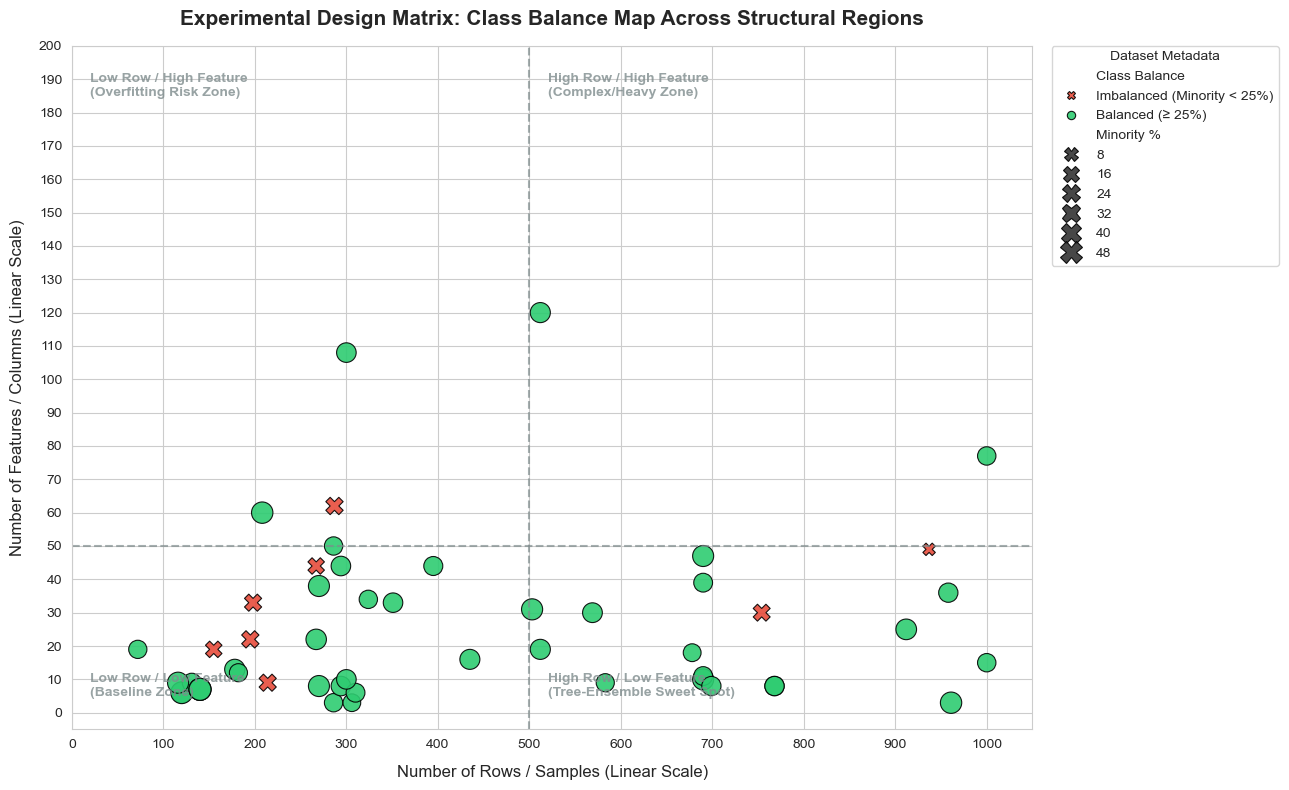

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Process the dictionary into the exact 52-dataset filtered dataframe
plot_data = []
for name, dataset_content in all_datasets.items():
    X = dataset_content['X']
    y = dataset_content['y'].flatten()
    
    total_samples = X.shape[0]
    num_features = X.shape[1]
    
    # Filter exactly matching your cross-tabulation table (Rows <= 1000 and Features < 200)
    if total_samples <= 1000 and num_features < 200:
        unique_labels = np.unique(y)
        if len(unique_labels) == 2:
            count_a = np.sum(y == unique_labels[0])
            count_b = np.sum(y == unique_labels[1])
            minority_pct = (min(count_a, count_b) / total_samples) * 100
        else:
            minority_pct = 50.0
            
        balance_type = "Balanced (≥ 25%)" if minority_pct >= 25.0 else "Imbalanced (Minority < 25%)"
        
        plot_data.append({
            "Dataset Name": name,
            "Rows": total_samples,
            "Features": num_features,
            "Class Balance": balance_type,
            "Minority %": minority_pct
        })

df_filtered = pd.DataFrame(plot_data)

# 2. Set up the plotting environment
plt.figure(figsize=(13, 8))
sns.set_style("whitegrid")

# Define high-contrast colors for Class Balance
# Green means healthy/standard, Red alerts you to anomaly handling
palette = {
    "Balanced (≥ 25%)": "#2ecc71",       # Emerald Green
    "Imbalanced (Minority < 25%)": "#e74c3c" # Alizarin Red
}

# 3. Generate the Scatter Plot
# Hue controls the color (Balance Type), size reflects the exact minority percentage
ax = sns.scatterplot(
    data=df_filtered,
    x="Rows",
    y="Features",
    hue="Class Balance",
    palette=palette,
    style="Class Balance",  # Different marker shapes for extra clarity
    markers={"Balanced (≥ 25%)": "o", "Imbalanced (Minority < 25%)": "X"},
    size="Minority %",
    sizes=(80, 250),
    alpha=0.9,
    edgecolor="black",
    linewidth=0.8
)

# 4. Draw Region Divider Lines (Thresholds: 500 Rows, 50 Features)
plt.axvline(x=500, color="#7f8c8d", linestyle="--", alpha=0.7, linewidth=1.5)
plt.axhline(y=50, color="#7f8c8d", linestyle="--", alpha=0.7, linewidth=1.5)

# 5. Label the 4 Structural Regions in the background corners of the plot
# Bottom-Left
plt.text(20, 5, "Low Row / Low Feature\n(Baseline Zone)", fontsize=10, color="#7f8c8d", weight="bold", alpha=0.8)
# Top-Left
plt.text(20, 185, "Low Row / High Feature\n(Overfitting Risk Zone)", fontsize=10, color="#7f8c8d", weight="bold", alpha=0.8)
# Bottom-Right
plt.text(520, 5, "High Row / Low Feature\n(Tree-Ensemble Sweet Spot)", fontsize=10, color="#7f8c8d", weight="bold", alpha=0.8)
# Top-Right
plt.text(520, 185, "High Row / High Feature\n(Complex/Heavy Zone)", fontsize=10, color="#7f8c8d", weight="bold", alpha=0.8)

# 6. Apply strict linear scales matching your constraints
plt.xlim(0, 1050)
plt.xticks(np.arange(0, 1100, 100)) # Clean tick marks every 100 rows

plt.ylim(-5, 200)
plt.yticks(np.arange(0, 210, 10))   # Clean tick marks every 10 features

# 7. Labels, Legends, and Titles
plt.title("Experimental Design Matrix: Class Balance Map Across Structural Regions", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Number of Rows / Samples (Linear Scale)", fontsize=12, labelpad=10)
plt.ylabel("Number of Features / Columns (Linear Scale)", fontsize=12, labelpad=10)

# Position legend cleanly outside to avoid obscuring any data points
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title="Dataset Metadata")

plt.tight_layout()
plt.savefig('balance', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

results_lr = []

print("Running Logistic Regression evaluation across 52 core datasets...")

for name, dataset_content in all_datasets.items():
    X = dataset_content['X']
    y = dataset_content['y'].flatten()
    
    total_samples = X.shape[0]
    num_features = X.shape[1]
    
    # Apply your exact visual majority filter (Rows <= 1000 and Features < 200)
    if total_samples <= 1000 and num_features < 200:
        
        # 1. Classify the structural region
        row_kind = "Low Row (<500)" if total_samples < 500 else "High Row (500-1000)"
        feat_kind = "Low Feature (<50)" if num_features < 50 else "High Feature (50-200)"
        region = f"{row_kind} & {feat_kind}"
        
        # 2. Safely calculate class balance percentage
        unique_labels = np.unique(y)
        if len(unique_labels) == 2:
            # Fix target labels to [0, 1] if they are non-standard
            if not np.array_equal(unique_labels, [0, 1]):
                y = np.where(y == unique_labels[0], 0, 1)
            
            count_a = np.sum(y == 0)
            count_b = np.sum(y == 1)
            minority_pct = (min(count_a, count_b) / total_samples) * 100
        else:
            minority_pct = 50.0
            
        balance_group = "Imbalanced (<25%)" if minority_pct < 25.0 else "Balanced (≥25%)"
        
        # 3. Scale features and evaluate using 3-Fold CV (ROC-AUC)
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        # Use class_weight='balanced' to ensure fair evaluation on the imbalanced sets
        model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
        
        try:
            scores = cross_val_score(model, X_scaled, y, cv=3, scoring='roc_auc')
            mean_auc = scores.mean()
        except:
            mean_auc = np.nan # Safeguard against tiny edge-case errors
            
        results_lr.append({
            "Dataset": name,
            "Structural Region": region,
            "Balance Group": balance_group,
            "LR ROC-AUC": mean_auc
        })

# Convert to DataFrame
df_lr_results = pd.DataFrame(results_lr)

# Generate a clean, high-level summary table grouped by your exact categories!
summary_table = df_lr_results.groupby(['Structural Region', 'Balance Group'])['LR ROC-AUC'].agg(['count', 'mean', 'min', 'max']).round(3)
summary_table.rename(columns={'count': 'Number of Datasets', 'mean': 'Average ROC-AUC'}, inplace=True)

summary_table

Running Logistic Regression evaluation across 52 core datasets...


Number of Datasets  \
Structural Region                           Balance Group                           
High Row (500-1000) & High Feature (50-200) Balanced (≥25%)                     2   
High Row (500-1000) & Low Feature (<50)     Balanced (≥25%)                    16   
                                            Imbalanced (<25%)                   2   
Low Row (<500) & High Feature (50-200)      Balanced (≥25%)                     3   
                                            Imbalanced (<25%)                   1   
Low Row (<500) & Low Feature (<50)          Balanced (≥25%)                    23   
                                            Imbalanced (<25%)                   5   

                                                               Average ROC-AUC  \
Structural Region                           Balance Group                        
High Row (500-1000) & High Feature (50-200) Balanced (≥25%)              0.623   
High Row (500-1000) & Low Feature (<50)     Balanced (≥25%)              0.793   
                                            Imbalanced (<25%)            0.744   
Low Row (<500) & High Feature (50-200)      Balanced (≥25%)              0.700   
                                            Imbalanced (<25%)            0.713   
Low Row (<500) & Low Feature (<50)          Balanced (≥25%)              0.828   
                                            Imbalanced (<25%)            0.856   

                                                                 min    max  
Structural Region                           Balance Group                    
High Row (500-1000) & High Feature (50-200) Balanced (≥25%)    0.464  0.781  
High Row (500-1000) & Low Feature (<50)     Balanced (≥25%)    0.467  0.994  
                                            Imbalanced (<25%)  0.637  0.852  
Low Row (<500) & High Feature (50-200)      Balanced (≥25%)    0.569  0.844  
                                            Imbalanced (<25%)  0.713  0.713  
Low Row (<500) & Low Feature (<50)          Balanced (≥25%)    0.415  1.000  
                                            Imbalanced (<25%)  0.810  0.907

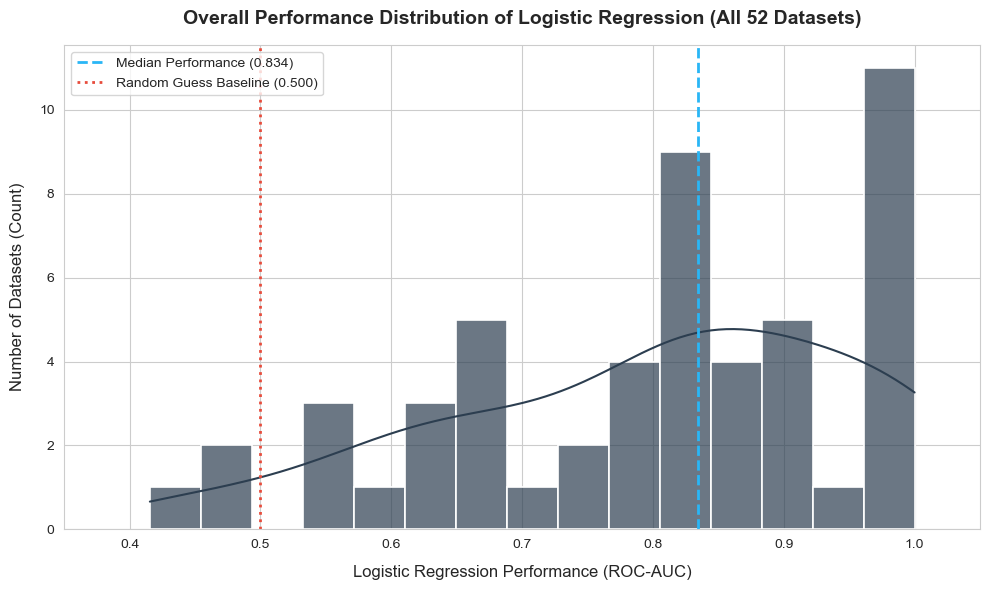

--- Distribution Statistics ---
count    52.000
mean      0.799
std       0.159
min       0.415
25%       0.684
50%       0.834
75%       0.912
max       1.000
Name: LR ROC-AUC, dtype: float64


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if 'df_lr_results' in locals() or 'df_lr_results' in globals():
    
    # Setup the single distribution plot
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")
    
    # Plot the overall distribution of the ROC-AUC scores
    sns.histplot(
        data=df_lr_results,
        x="LR ROC-AUC",
        kde=True,               # Adds the smooth density line over the bars
        color="#2c3e50",        # Deep slate color
        bins=15,                # Granularity of performance buckets
        edgecolor="white",
        linewidth=1.2,
        alpha=0.7
    )
    
    # 1. Add a vertical line for the median performance
    median_auc = df_lr_results['LR ROC-AUC'].median()
    plt.axvline(x=median_auc, color="#29b6f6", linestyle="--", linewidth=2, 
                label=f"Median Performance ({median_auc:.3f})")
    
    # 2. Add a vertical line for the Random Guess Baseline
    plt.axvline(x=0.5, color="#e74c3c", linestyle=":", linewidth=2, 
                label="Random Guess Baseline (0.500)")
    
    # Formatting
    plt.title("Overall Performance Distribution of Logistic Regression (All 52 Datasets)", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Logistic Regression Performance (ROC-AUC)", fontsize=12, labelpad=10)
    plt.ylabel("Number of Datasets (Count)", fontsize=12, labelpad=10)
    
    plt.xlim(0.35, 1.05)
    plt.xticks(np.arange(0.4, 1.1, 0.1))
    
    plt.legend(loc="upper left", frameon=True)
    plt.tight_layout()
    plt.savefig('LR_Performance', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print out raw descriptive stats for your notes
    print("--- Distribution Statistics ---")
    print(df_lr_results['LR ROC-AUC'].describe().round(3))
     

else:
    print("❌ Error: Run your Logistic Regression cell first to generate df_lr_results!")

In [ ]:
print(f"Percentage above 0.8: {(df_lr_results['LR ROC-AUC'] > 0.8).mean() * 100:.2f}%")
print(f"Exact count: {sum(df_lr_results['LR ROC-AUC'] > 0.8)} out of {len(df_lr_results)}")

Percentage above 0.8: 57.69%
Exact count: 30 out of 52


🌲 Running Random Forest evaluation across 52 core datasets...


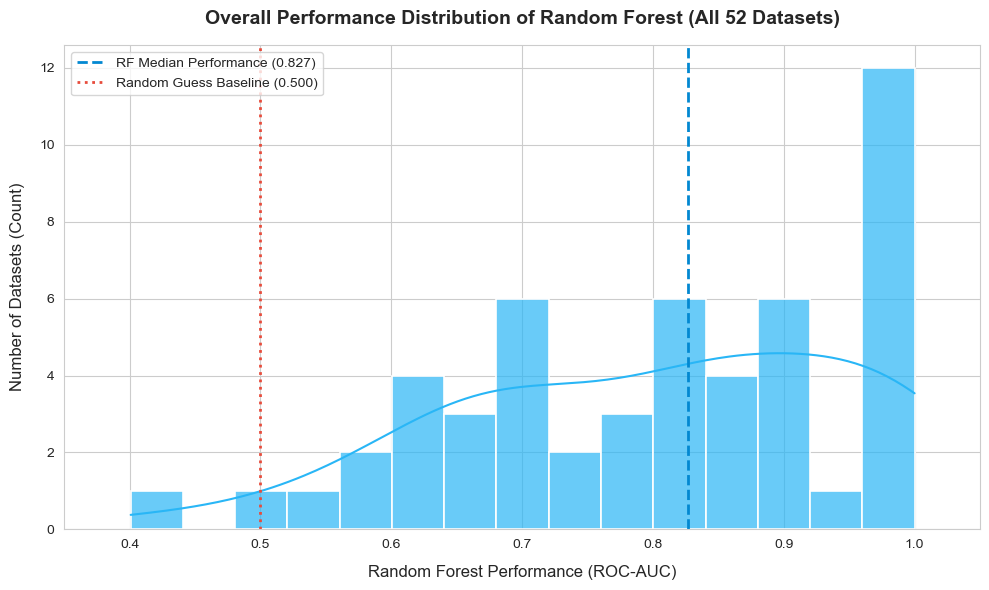

--- Random Forest Distribution Statistics ---
count    52.000
mean      0.803
std       0.153
min       0.401
25%       0.691
50%       0.827
75%       0.919
max       1.000
Name: RF ROC-AUC, dtype: float64

--- Summary Threshold ---
Percentage above 0.8: 55.77%
Exact count: 29 out of 52


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

results_rf = []

print("🌲 Running Random Forest evaluation across 52 core datasets...")

for name, dataset_content in all_datasets.items():
    X = dataset_content['X']
    y = dataset_content['y'].flatten()
    
    total_samples = X.shape[0]
    num_features = X.shape[1]
    
    # Keep the exact same 52-dataset filter (Rows <= 1000 and Features < 200)
    if total_samples <= 1000 and num_features < 200:
        unique_labels = np.unique(y)
        if not np.array_equal(unique_labels, [0, 1]):
            y = np.where(y == unique_labels[0], 0, 1)
            
        # Initialize Random Forest with class balancing turned ON
        model_rf = RandomForestClassifier(class_weight='balanced', random_state=42)
        
        try:
            scores = cross_val_score(model_rf, X, y, cv=3, scoring='roc_auc')
            mean_auc = scores.mean()
        except:
            mean_auc = np.nan
            
        results_rf.append({
            "Dataset": name,
            "RF ROC-AUC": mean_auc
        })

# Convert to DataFrame
df_rf_results = pd.DataFrame(results_rf)

# 1. Setup the Single Distribution Plot
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Plot the overall distribution of Random Forest ROC-AUC scores
sns.histplot(
    data=df_rf_results,
    x="RF ROC-AUC",
    kde=True,               # Adds the smooth density line over the bars
    color="#29b6f6",        # Bright blue color for Random Forest
    bins=15,                # Same granularity as before
    edgecolor="white",
    linewidth=1.2,
    alpha=0.7
)

# 2. Add a vertical line for the median performance
median_rf_auc = df_rf_results['RF ROC-AUC'].median()
plt.axvline(x=median_rf_auc, color="#0288d1", linestyle="--", linewidth=2, 
            label=f"RF Median Performance ({median_rf_auc:.3f})")

# 3. Add a vertical line for the Random Guess Baseline
plt.axvline(x=0.5, color="#e74c3c", linestyle=":", linewidth=2, 
            label="Random Guess Baseline (0.500)")

# Formatting
plt.title("Overall Performance Distribution of Random Forest (All 52 Datasets)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Random Forest Performance (ROC-AUC)", fontsize=12, labelpad=10)
plt.ylabel("Number of Datasets (Count)", fontsize=12, labelpad=10)

plt.xlim(0.35, 1.05)
plt.xticks(np.arange(0.4, 1.1, 0.1))
plt.legend(loc="upper left", frameon=True)

plt.tight_layout()
plt.show()

# 4. Print out metrics and percentage above 0.8
pct_above_08 = (df_rf_results['RF ROC-AUC'] > 0.8).mean() * 100
count_above_08 = sum(df_rf_results['RF ROC-AUC'] > 0.8)

print("--- Random Forest Distribution Statistics ---")
print(df_rf_results['RF ROC-AUC'].describe().round(3))
print("\n--- Summary Threshold ---")
print(f"Percentage above 0.8: {pct_above_08:.2f}%")
print(f"Exact count: {count_above_08} out of {len(df_rf_results)}")

🌲 Running Random Forest evaluation across 52 core datasets...


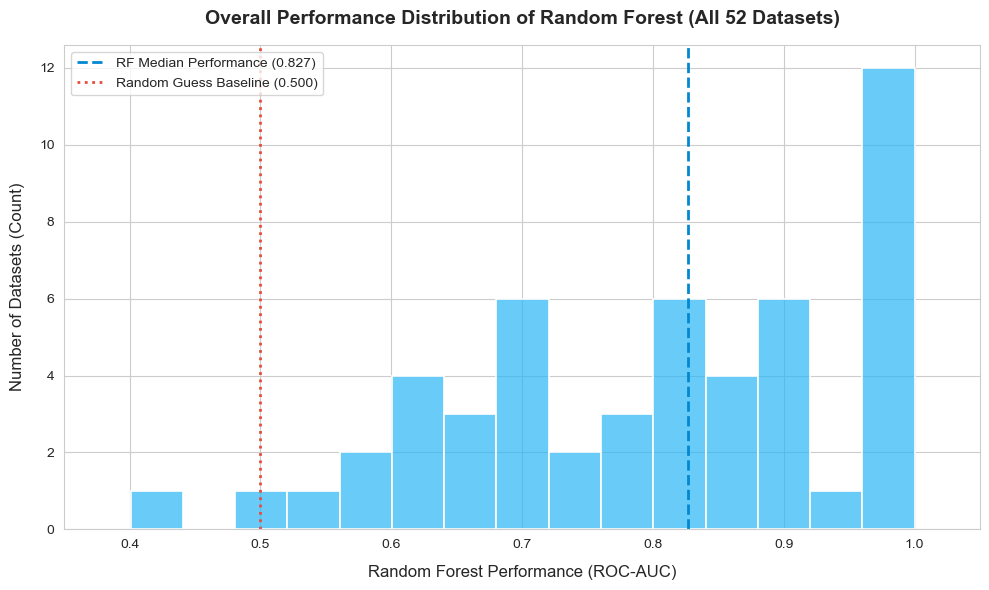

--- Random Forest Distribution Statistics ---
count    52.000
mean      0.803
std       0.153
min       0.401
25%       0.691
50%       0.827
75%       0.919
max       1.000
Name: RF ROC-AUC, dtype: float64

--- Summary Threshold ---
Percentage above 0.8: 55.77%
Exact count: 29 out of 52


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

results_rf = []

print("🌲 Running Random Forest evaluation across 52 core datasets...")

for name, dataset_content in all_datasets.items():
    X = dataset_content['X']
    y = dataset_content['y'].flatten()
    
    total_samples = X.shape[0]
    num_features = X.shape[1]
    
    if total_samples <= 1000 and num_features < 200:
        unique_labels = np.unique(y)
        if not np.array_equal(unique_labels, [0, 1]):
            y = np.where(y == unique_labels[0], 0, 1)
            
        model_rf = RandomForestClassifier(class_weight='balanced', random_state=42)
        
        try:
            scores = cross_val_score(model_rf, X, y, cv=3, scoring='roc_auc')
            mean_auc = scores.mean()
        except:
            mean_auc = np.nan
            
        results_rf.append({
            "Dataset": name,
            "RF ROC-AUC": mean_auc
        })

df_rf_results = pd.DataFrame(results_rf)

# Setup the Single Distribution Plot
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Plot the overall distribution of Random Forest ROC-AUC scores (LINE REMOVED)
sns.histplot(
    data=df_rf_results,
    x="RF ROC-AUC",
    kde=False,              # <--- Changed to False to remove the curve line
    color="#29b6f6",        
    bins=15,                
    edgecolor="white",
    linewidth=1.2,
    alpha=0.7
)

# Vertical line for the median performance
median_rf_auc = df_rf_results['RF ROC-AUC'].median()
plt.axvline(x=median_rf_auc, color="#0288d1", linestyle="--", linewidth=2, 
            label=f"RF Median Performance ({median_rf_auc:.3f})")

# Vertical line for the Random Guess Baseline
plt.axvline(x=0.5, color="#e74c3c", linestyle=":", linewidth=2, 
            label="Random Guess Baseline (0.500)")

# Formatting
plt.title("Overall Performance Distribution of Random Forest (All 52 Datasets)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Random Forest Performance (ROC-AUC)", fontsize=12, labelpad=10)
plt.ylabel("Number of Datasets (Count)", fontsize=12, labelpad=10)

plt.xlim(0.35, 1.05)
plt.xticks(np.arange(0.4, 1.1, 0.1))
plt.legend(loc="upper left", frameon=True)

plt.tight_layout()
plt.savefig('RF_Performance', dpi=300, bbox_inches='tight')
plt.show()

# Print out metrics
print("--- Random Forest Distribution Statistics ---")
print(df_rf_results['RF ROC-AUC'].describe().round(3))
print("\n--- Summary Threshold ---")
print(f"Percentage above 0.8: {(df_rf_results['RF ROC-AUC'] > 0.8).mean() * 100:.2f}%")
print(f"Exact count: {sum(df_rf_results['RF ROC-AUC'] > 0.8)} out of {len(df_rf_results)}")

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

dataset_correlations = []

print("Calculating model rank correlation for each dataset...")

for name, dataset_content in all_datasets.items():
    X = dataset_content['X']
    y = dataset_content['y'].flatten()
    
    total_samples = X.shape[0]
    num_features = X.shape[1]
    
    # Target your 52 core datasets
    if total_samples <= 1000 and num_features < 200:
        unique_labels = np.unique(y)
        if not np.array_equal(unique_labels, [0, 1]):
            y = np.where(y == unique_labels[0], 0, 1)
            
        # 1. Scale features for Logistic Regression accuracy
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        # 2. Fit Logistic Regression & get importances (absolute coefficients)
        model_lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
        model_lr.fit(X_scaled, y)
        lr_importances = np.abs(model_lr.coef_[0])
        
        # 3. Fit Random Forest & get importances (MDI)
        model_rf = RandomForestClassifier(class_weight='balanced', random_state=42)
        model_rf.fit(X, y)
        rf_importances = model_rf.feature_importances_
        
        # 4. Calculate Spearman correlation between the two importance arrays
        # (This measures how similarly the two models ranked the features)
        if len(lr_importances) > 1:
            corr, _ = spearmanr(lr_importances, rf_importances)
        else:
            corr = np.nan # Can't correlate a single feature
            
        dataset_correlations.append({
            "Dataset": name,
            "Rows": total_samples,
            "Features": num_features,
            "Model_Rank_Correlation": corr
        })

# Convert to a clean DataFrame table
df_model_corr = pd.DataFrame(dataset_correlations)

# Sort by correlation descending so you can see where they agree vs disagree
df_model_corr = df_model_corr.sort_values(by="Model_Rank_Correlation", ascending=False).reset_index(drop=True)
df_model_corr.round(3)

Calculating model rank correlation for each dataset...


,Dataset,Rows,Features,Model_Rank_Correlation
0,'mammographic',961,3,1.000
1,'breast-cancer-1',286,3,1.000
2,'tic-tac-toe',958,36,0.921
3,'breast-cancer-coimbra',116,9,0.900
4,'acute-nephritis',120,6,0.886
5,'seed-3',140,7,0.786
6,'pima',768,8,0.762
7,'pima-indian-not-normalized',768,8,0.762
8,'seed-1',140,7,0.750
9,'echocardiogram',131,9,0.717


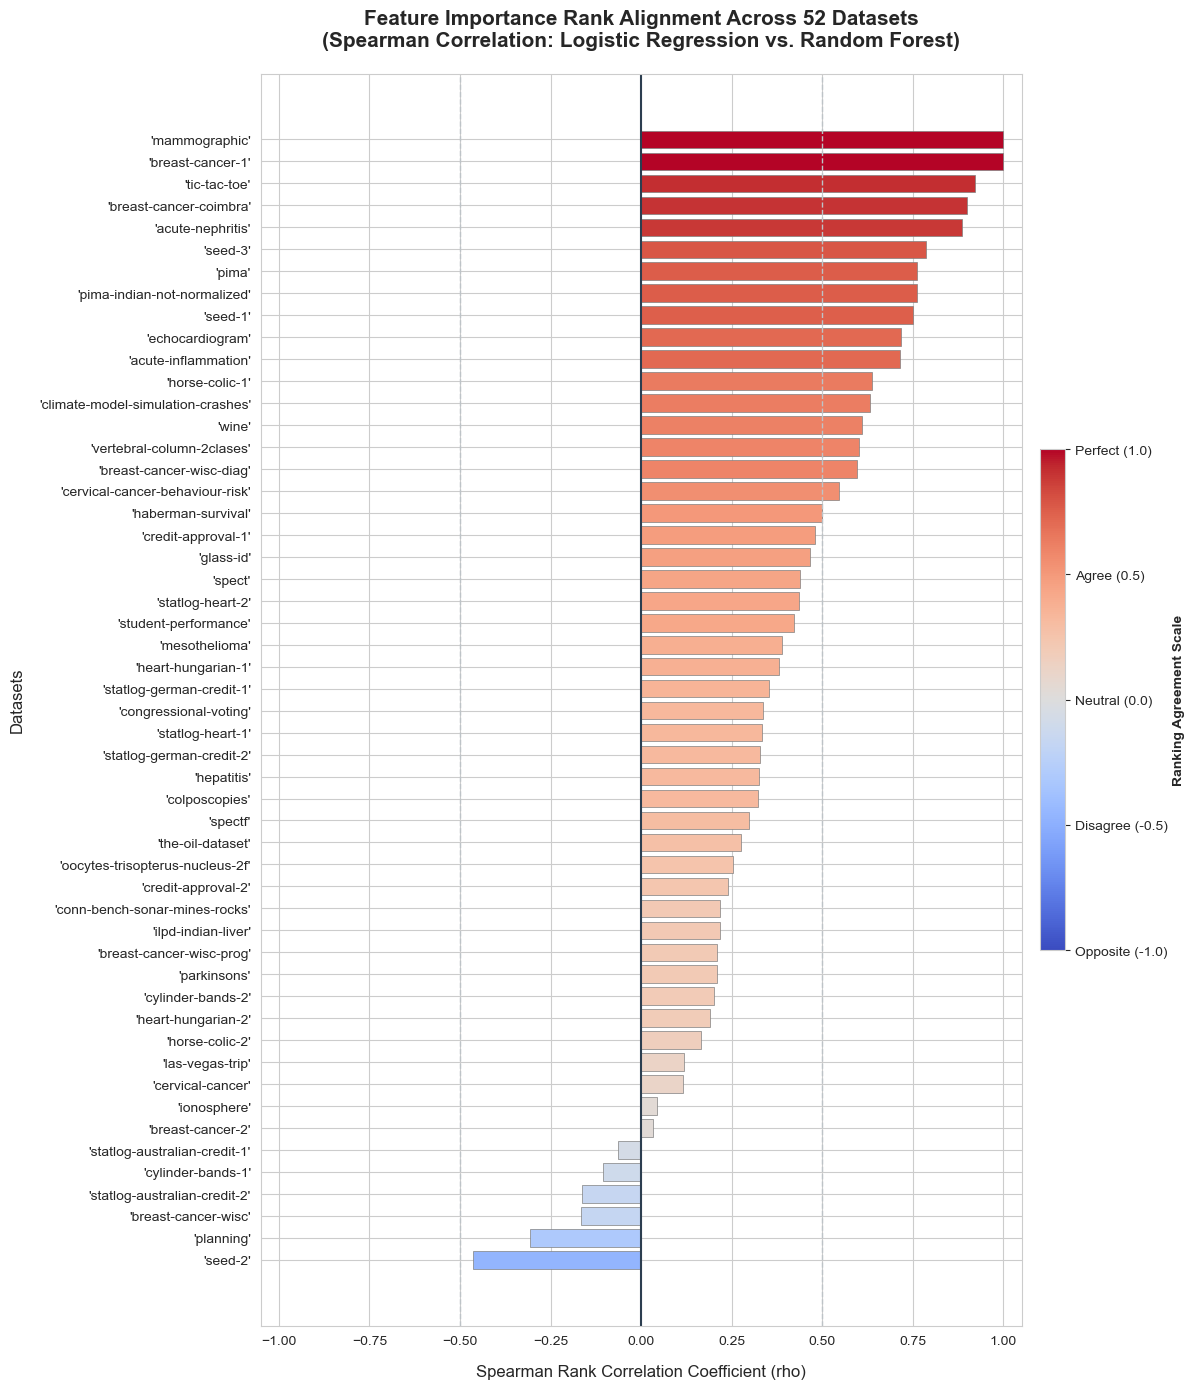

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# 1. Setup the figure size to comfortably fit all 52 dataset labels
plt.figure(figsize=(12, 14))
sns.set_style("whitegrid")

# FIX 1: Use the updated, modern way to fetch the colormap to prevent warnings
cmap = plt.colormaps.get_cmap('coolwarm')
norm = plt.Normalize(vmin=-1, vmax=1)
colors = cmap(norm(df_model_corr['Model_Rank_Correlation'].fillna(0).values))

# 2. Create the horizontal bar plot
bars = plt.barh(
    y=df_model_corr['Dataset'], 
    width=df_model_corr['Model_Rank_Correlation'].fillna(0), 
    color=colors,
    edgecolor='grey',
    linewidth=0.5
)

# 3. Add reference lines at 0.0, 0.5, and -0.5
plt.axvline(x=0, color='#2c3e50', linestyle='-', linewidth=1.5)
plt.axvline(x=0.5, color='#bdc3c7', linestyle='--', linewidth=1)
plt.axvline(x=-0.5, color='#bdc3c7', linestyle='--', linewidth=1)

# 4. Invert the Y-axis so the highest correlations are at the top
plt.gca().invert_yaxis()

# 5. Formatting titles and labels
plt.title("Feature Importance Rank Alignment Across 52 Datasets\n(Spearman Correlation: Logistic Regression vs. Random Forest)", 
          fontsize=15, fontweight='bold', pad=20)

# FIX 2: Removed the raw math formatting token ($\rho$) that caused the tight_layout crash
plt.xlabel("Spearman Rank Correlation Coefficient (rho)", fontsize=12, labelpad=12)
plt.ylabel("Datasets", fontsize=12, labelpad=10)

# Limit x-axis to the valid correlation bounds
plt.xlim(-1.05, 1.05)

# 6. Add a subtle colorbar on the side to serve as a visual legend
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), shrink=0.4, pad=0.02)
cbar.set_label("Ranking Agreement Scale", fontsize=10, fontweight='bold')
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
cbar.set_ticklabels(["Opposite (-1.0)", "Disagree (-0.5)", "Neutral (0.0)", "Agree (0.5)", "Perfect (1.0)"])

plt.tight_layout()
plt.savefig('Corr', dpi=300, bbox_inches='tight')
plt.show()

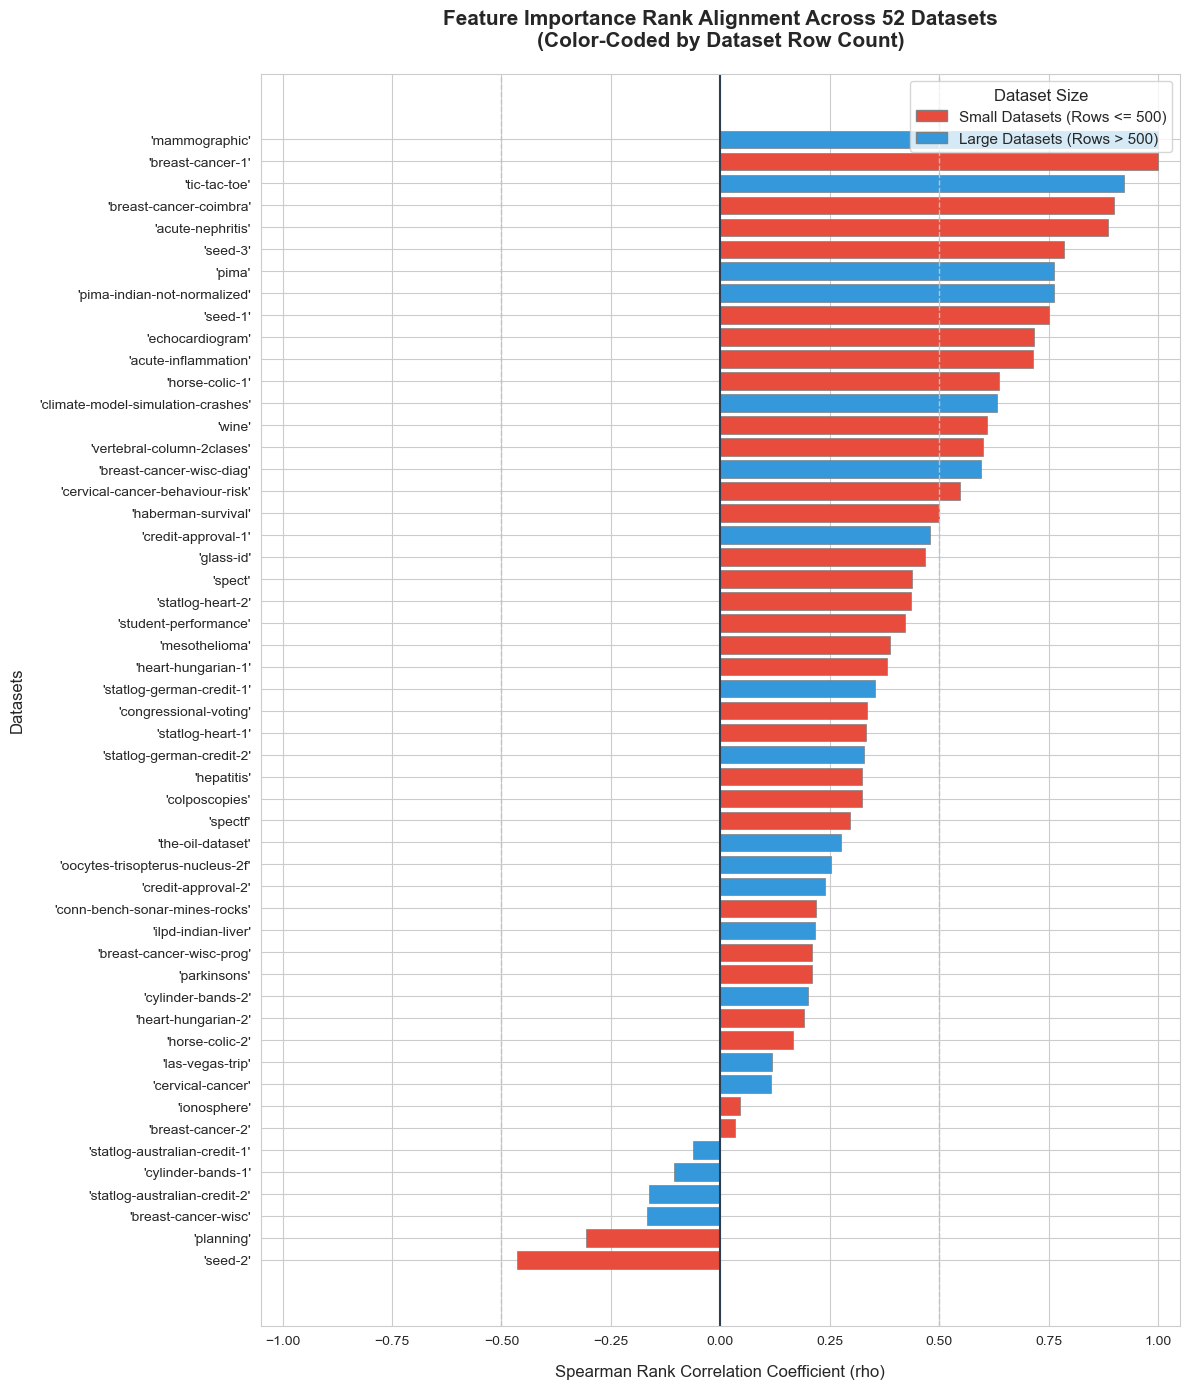

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# 1. Setup the figure size to comfortably fit all 52 dataset labels
plt.figure(figsize=(12, 14))
sns.set_style("whitegrid")

# 2. Assign colors dynamically based on the 500 rows threshold
# Red (#e74c3c) for <= 500 rows, Blue (#3498db) for > 500 rows
colors = ['#e74c3c' if r <= 500 else '#3498db' for r in df_model_corr['Rows']]

# 3. Create the horizontal bar plot
bars = plt.barh(
    y=df_model_corr['Dataset'], 
    width=df_model_corr['Model_Rank_Correlation'].fillna(0), 
    color=colors,
    edgecolor='grey',
    linewidth=0.5
)

# 4. Add reference guidelines at 0.0, 0.5, and -0.5
plt.axvline(x=0, color='#2c3e50', linestyle='-', linewidth=1.5)
plt.axvline(x=0.5, color='#bdc3c7', linestyle='--', linewidth=1)
plt.axvline(x=-0.5, color='#bdc3c7', linestyle='--', linewidth=1)

# 5. Invert the Y-axis so highest correlations stay at the top
plt.gca().invert_yaxis()

# 6. Formatting titles and labels
plt.title("Feature Importance Rank Alignment Across 52 Datasets\n(Color-Coded by Dataset Row Count)", 
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Spearman Rank Correlation Coefficient (rho)", fontsize=12, labelpad=12)
plt.ylabel("Datasets", fontsize=12, labelpad=10)

# Limit x-axis to the valid correlation bounds
plt.xlim(-1.05, 1.05)

# 7. Add a custom categorical legend instead of the old gradient colorbar
legend_elements = [
    Patch(facecolor='#e74c3c', edgecolor='grey', label='Small Datasets (Rows <= 500)'),
    Patch(facecolor='#3498db', edgecolor='grey', label='Large Datasets (Rows > 500)')
]
plt.legend(handles=legend_elements, loc='upper right', title="Dataset Size", fontsize=11, title_fontsize=12)

plt.tight_layout()
plt.savefig('corr_row', dpi=300, bbox_inches='tight')
plt.show()

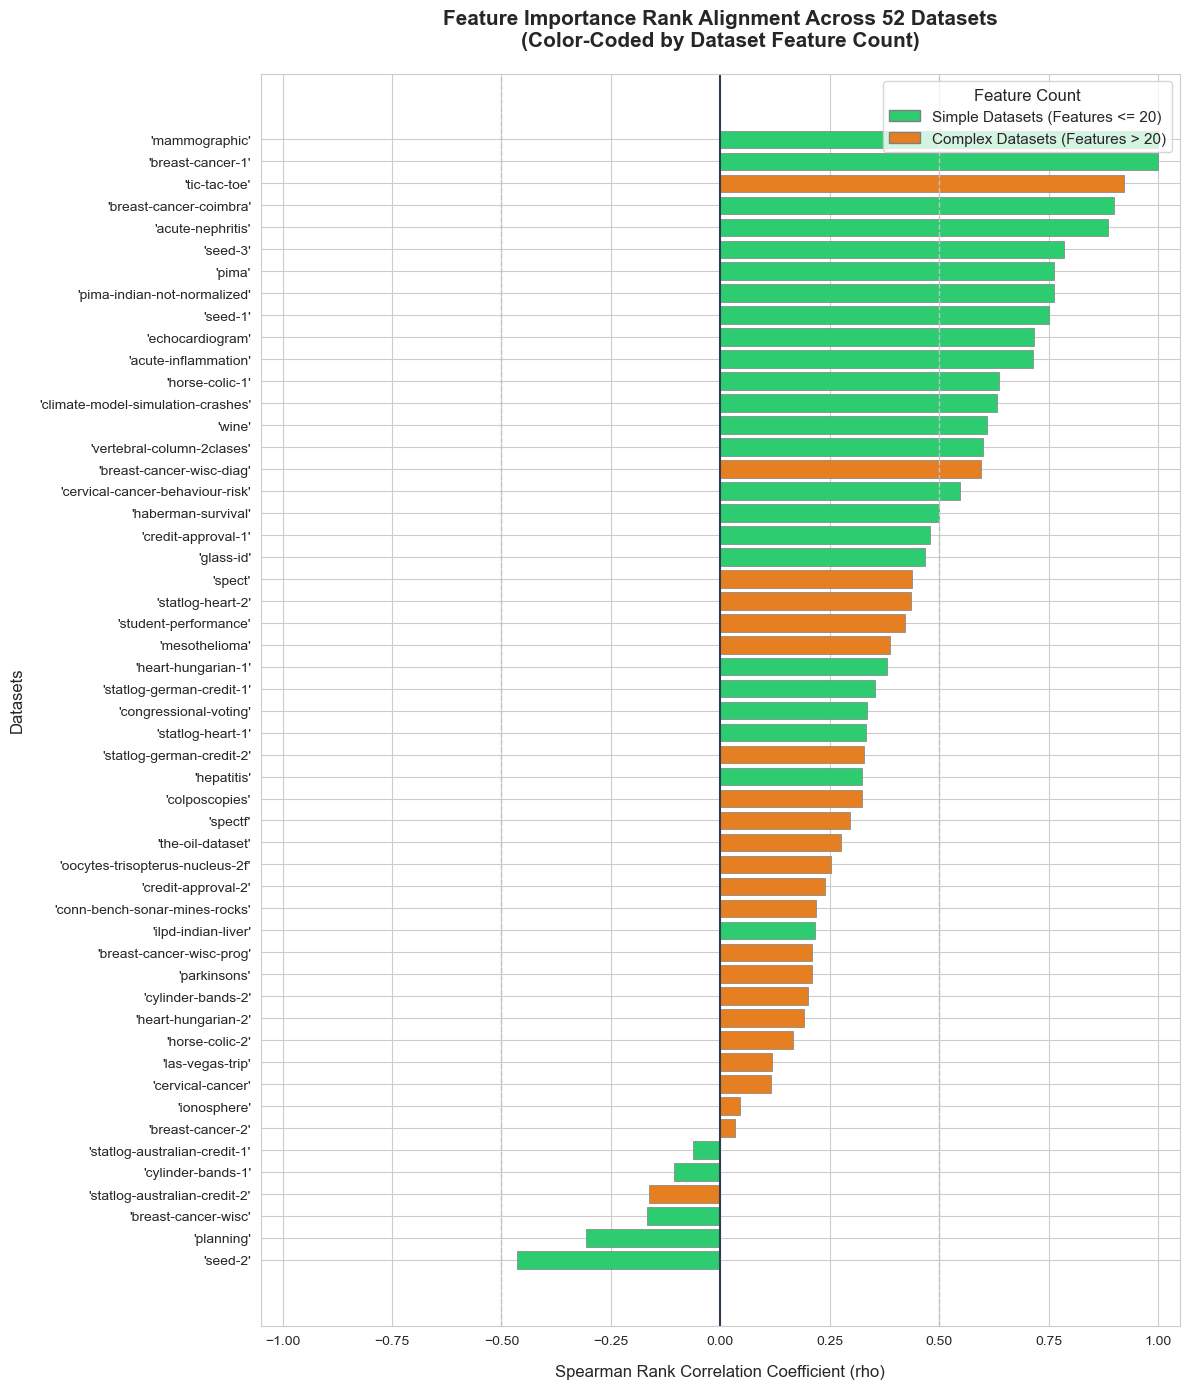

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# 1. Setup the figure size to comfortably fit all 52 dataset labels
plt.figure(figsize=(12, 14))
sns.set_style("whitegrid")

# 2. Assign colors dynamically based on the 20 features threshold
# Green (#2ecc71) for <= 20 features, Orange (#e67e22) for > 20 features
colors = ['#2ecc71' if f <= 20 else '#e67e22' for f in df_model_corr['Features']]

# 3. Create the horizontal bar plot
bars = plt.barh(
    y=df_model_corr['Dataset'], 
    width=df_model_corr['Model_Rank_Correlation'].fillna(0), 
    color=colors,
    edgecolor='grey',
    linewidth=0.5
)

# 4. Add reference guidelines at 0.0, 0.5, and -0.5
plt.axvline(x=0, color='#2c3e50', linestyle='-', linewidth=1.5)
plt.axvline(x=0.5, color='#bdc3c7', linestyle='--', linewidth=1)
plt.axvline(x=-0.5, color='#bdc3c7', linestyle='--', linewidth=1)

# 5. Invert the Y-axis so highest correlations stay at the top
plt.gca().invert_yaxis()

# 6. Formatting titles and labels
plt.title("Feature Importance Rank Alignment Across 52 Datasets\n(Color-Coded by Dataset Feature Count)", 
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Spearman Rank Correlation Coefficient (rho)", fontsize=12, labelpad=12)
plt.ylabel("Datasets", fontsize=12, labelpad=10)

# Limit x-axis to the valid correlation bounds
plt.xlim(-1.05, 1.05)

# 7. Add a custom categorical legend for features
legend_elements = [
    Patch(facecolor='#2ecc71', edgecolor='grey', label='Simple Datasets (Features <= 20)'),
    Patch(facecolor='#e67e22', edgecolor='grey', label='Complex Datasets (Features > 20)')
]
plt.legend(handles=legend_elements, loc='upper right', title="Feature Count", fontsize=11, title_fontsize=12)

plt.tight_layout()
plt.savefig('LR_Performance', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Create the row-count group flags
df_model_corr['Row_Group'] = df_model_corr['Rows'].apply(lambda x: 'Small (<= 500 rows)' if x <= 500 else 'Large (> 500 rows)')

# Aggregate into a summary table
row_summary = df_model_corr['Row_Group'].value_counts().reset_index()
row_summary.columns = ['Dataset Size Category', 'Dataset Count']
row_summary

,Dataset Size Category,Dataset Count
0,Small (<= 500 rows),32
1,Large (> 500 rows),20


In [ ]:
# Create the feature-count group flags
df_model_corr['Feature_Group'] = df_model_corr['Features'].apply(lambda x: 'Simple (<= 20 features)' if x <= 20 else 'Complex (> 20 features)')

# Aggregate into a summary table
feature_summary = df_model_corr['Feature_Group'].value_counts().reset_index()
feature_summary.columns = ['Feature Complexity Category', 'Dataset Count']
feature_summary

,Feature Complexity Category,Dataset Count
0,Simple (<= 20 features),29
1,Complex (> 20 features),23


In [ ]:
def assign_meta_group(row):
    r = row['Rows']
    f = row['Features']
    if r <= 500 and f <= 20:
        return "Small & Simple (Rows <= 500, Feat <= 20)"
    elif r <= 500 and f > 20:
        return "Low Row / High Feat (Rows <= 500, Feat > 20)"
    elif r > 500 and f <= 20:
        return "High Row / Low Feat (Rows > 500, Feat <= 20)"
    else:
        return "Big & Complex (Rows > 500, Feat > 20)"

# Assign the four structural quadrants
df_model_corr['Meta_Group'] = df_model_corr.apply(assign_meta_group, axis=1)

# Generate the summary layout table
quadrant_summary = df_model_corr['Meta_Group'].value_counts().reset_index()
quadrant_summary.columns = ['Structural Category', 'Dataset Count']
quadrant_summary

,Structural Category,Dataset Count
0,"Small & Simple (Rows <= 500, Feat <= 20)",19
1,"Low Row / High Feat (Rows <= 500, Feat > 20)",13
2,"High Row / Low Feat (Rows > 500, Feat <= 20)",10
3,"Big & Complex (Rows > 500, Feat > 20)",10


In [ ]:
def assign_meta_group(row):
    r = row['Rows']
    f = row['Features']
    if r <= 500 and f <= 20:
        return "Small & Simple (Rows <= 500, Feat <= 20)"
    elif r <= 500 and f > 20:
        return "Low Row / High Feat (Rows <= 500, Feat > 20)"
    elif r > 500 and f <= 20:
        return "High Row / Low Feat (Rows > 500, Feat <= 20)"
    else:
        return "Big & Complex (Rows > 500, Feat > 20)"

# Assign the four structural quadrants
df_model_corr['Meta_Group'] = df_model_corr.apply(assign_meta_group, axis=1)

# Generate the summary layout table
quadrant_summary = df_model_corr['Meta_Group'].value_counts().reset_index()
quadrant_summary.columns = ['Structural Category', 'Dataset Count']
quadrant_summary

,Structural Category,Dataset Count
0,"Small & Simple (Rows <= 500, Feat <= 20)",19
1,"Low Row / High Feat (Rows <= 500, Feat > 20)",13
2,"High Row / Low Feat (Rows > 500, Feat <= 20)",10
3,"Big & Complex (Rows > 500, Feat > 20)",10


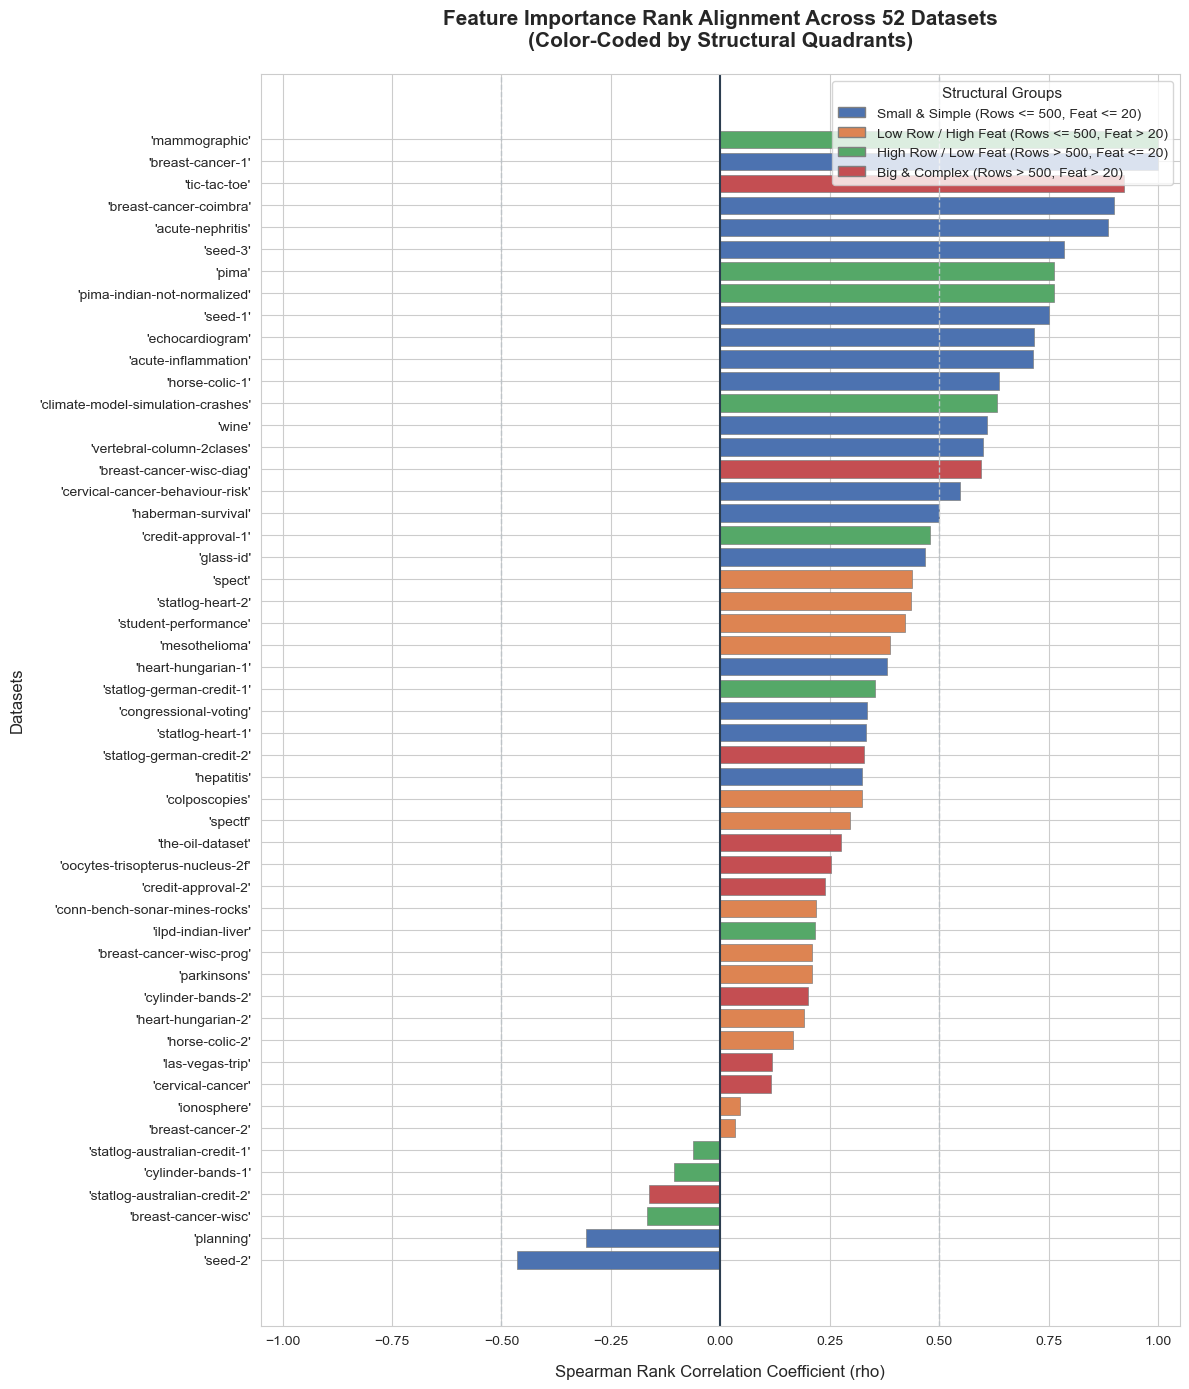

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# 1. Setup the figure size to comfortably fit all 52 dataset labels
plt.figure(figsize=(12, 14))
sns.set_style("whitegrid")

# 2. Map the categories to your explicit notebook palette colors
group_palette = {
    "Small & Simple (Rows <= 500, Feat <= 20)": "#4C72B0",      # Muted Blue
    "Low Row / High Feat (Rows <= 500, Feat > 20)": "#DD8452",   # Orange
    "High Row / Low Feat (Rows > 500, Feat <= 20)": "#55A868",   # Green
    "Big & Complex (Rows > 500, Feat > 20)": "#C44E52"           # Red
}
colors = [group_palette[g] for g in df_model_corr['Meta_Group']]

# 3. Create the horizontal bar plot
bars = plt.barh(
    y=df_model_corr['Dataset'], 
    width=df_model_corr['Model_Rank_Correlation'].fillna(0), 
    color=colors,
    edgecolor='grey',
    linewidth=0.5
)

# 4. Add reference guidelines at 0.0, 0.5, and -0.5
plt.axvline(x=0, color='#2c3e50', linestyle='-', linewidth=1.5)
plt.axvline(x=0.5, color='#bdc3c7', linestyle='--', linewidth=1)
plt.axvline(x=-0.5, color='#bdc3c7', linestyle='--', linewidth=1)

# 5. Invert the Y-axis so highest correlations stay at the top
plt.gca().invert_yaxis()

# 6. Formatting titles and labels
plt.title("Feature Importance Rank Alignment Across 52 Datasets\n(Color-Coded by Structural Quadrants)", 
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Spearman Rank Correlation Coefficient (rho)", fontsize=12, labelpad=12)
plt.ylabel("Datasets", fontsize=12, labelpad=10)

# Limit x-axis to the valid correlation bounds
plt.xlim(-1.05, 1.05)

# 7. Add custom 4-color legend
legend_elements = [Patch(facecolor=color, edgecolor='grey', label=label) for label, color in group_palette.items()]
plt.legend(handles=legend_elements, loc='upper right', title="Structural Groups", fontsize=10, title_fontsize=11)

plt.tight_layout()
plt.show()

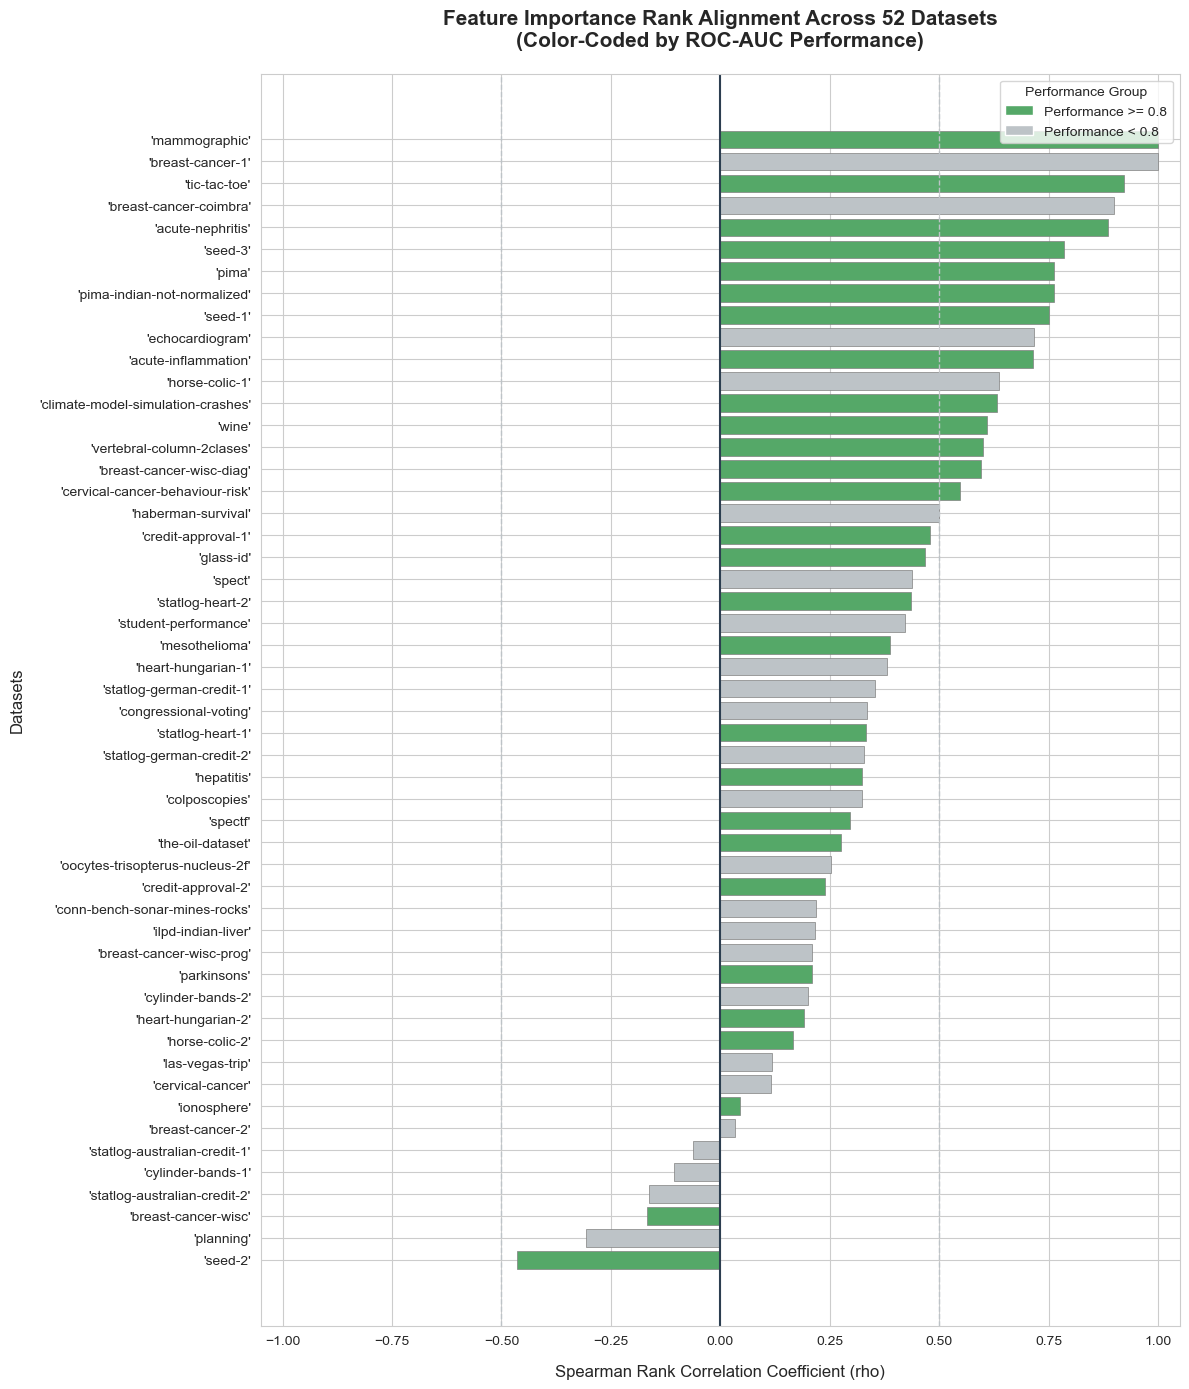

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 1. Merge to ensure we have the performance data
df_analysis = pd.merge(df_lr_results, df_rf_results, on="Dataset")
df_analysis = pd.merge(df_analysis, df_model_corr, on="Dataset")
df_analysis['Avg ROC-AUC'] = (df_analysis['LR ROC-AUC'] + df_analysis['RF ROC-AUC']) / 2

# 2. Sort by correlation for better readability and define colors
df_plot = df_analysis.sort_values('Model_Rank_Correlation', ascending=True)
colors = ['#55A868' if x >= 0.8 else '#bdc3c7' for x in df_plot['Avg ROC-AUC']]

# 3. Create the horizontal bar plot
plt.figure(figsize=(12, 14))
plt.barh(y=df_plot['Dataset'], width=df_plot['Model_Rank_Correlation'], color=colors, edgecolor='grey', linewidth=0.5)

# 4. Add guidelines
plt.axvline(x=0, color='#2c3e50', linestyle='-', linewidth=1.5)
plt.axvline(x=0.5, color='#bdc3c7', linestyle='--', linewidth=1)
plt.axvline(x=-0.5, color='#bdc3c7', linestyle='--', linewidth=1)

# 5. Formatting
plt.title("Feature Importance Rank Alignment Across 52 Datasets\n(Color-Coded by ROC-AUC Performance)", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Spearman Rank Correlation Coefficient (rho)", fontsize=12, labelpad=12)
plt.ylabel("Datasets", fontsize=12, labelpad=10)
plt.xlim(-1.05, 1.05)

# 6. Add custom legend
legend_elements = [
    Patch(facecolor='#55A868', label='Performance >= 0.8'),
    Patch(facecolor='#bdc3c7', label='Performance < 0.8')
]
plt.legend(handles=legend_elements, loc='upper right', title="Performance Group", fontsize=10)

plt.tight_layout()
plt.show()

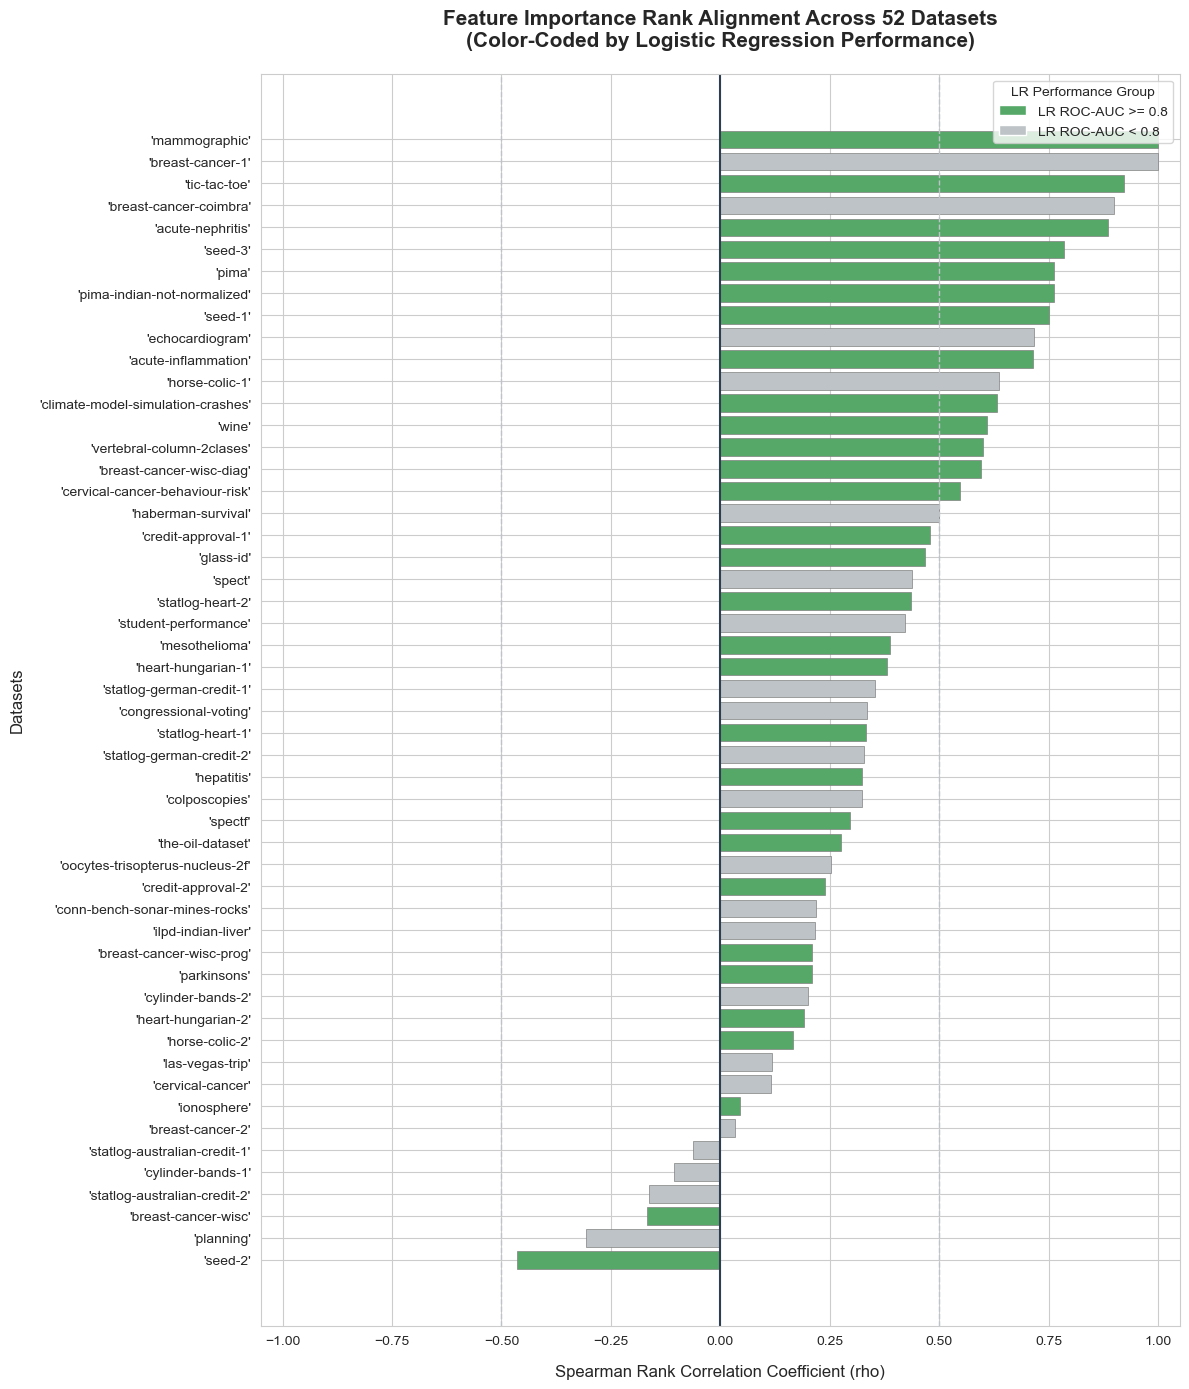

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 1. Use the existing df_analysis (from your previous cell)
# Ensure it contains 'LR ROC-AUC' and 'Model_Rank_Correlation'
df_plot = df_analysis.sort_values('Model_Rank_Correlation', ascending=True)

# 2. Define colors based specifically on LR ROC-AUC
# Green if LR performs >= 0.8, Grey otherwise
colors = ['#55A868' if x >= 0.8 else '#bdc3c7' for x in df_plot['LR ROC-AUC']]

# 3. Create the horizontal bar plot
plt.figure(figsize=(12, 14))
plt.barh(y=df_plot['Dataset'], width=df_plot['Model_Rank_Correlation'], color=colors, edgecolor='grey', linewidth=0.5)

# 4. Add guidelines
plt.axvline(x=0, color='#2c3e50', linestyle='-', linewidth=1.5)
plt.axvline(x=0.5, color='#bdc3c7', linestyle='--', linewidth=1)
plt.axvline(x=-0.5, color='#bdc3c7', linestyle='--', linewidth=1)

# 5. Formatting
plt.title("Feature Importance Rank Alignment Across 52 Datasets\n(Color-Coded by Logistic Regression Performance)", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Spearman Rank Correlation Coefficient (rho)", fontsize=12, labelpad=12)
plt.ylabel("Datasets", fontsize=12, labelpad=10)
plt.xlim(-1.05, 1.05)

# 6. Add custom legend
legend_elements = [
    Patch(facecolor='#55A868', label='LR ROC-AUC >= 0.8'),
    Patch(facecolor='#bdc3c7', label='LR ROC-AUC < 0.8')
]
plt.legend(handles=legend_elements, loc='upper right', title="LR Performance Group", fontsize=10)

plt.tight_layout()
plt.show()

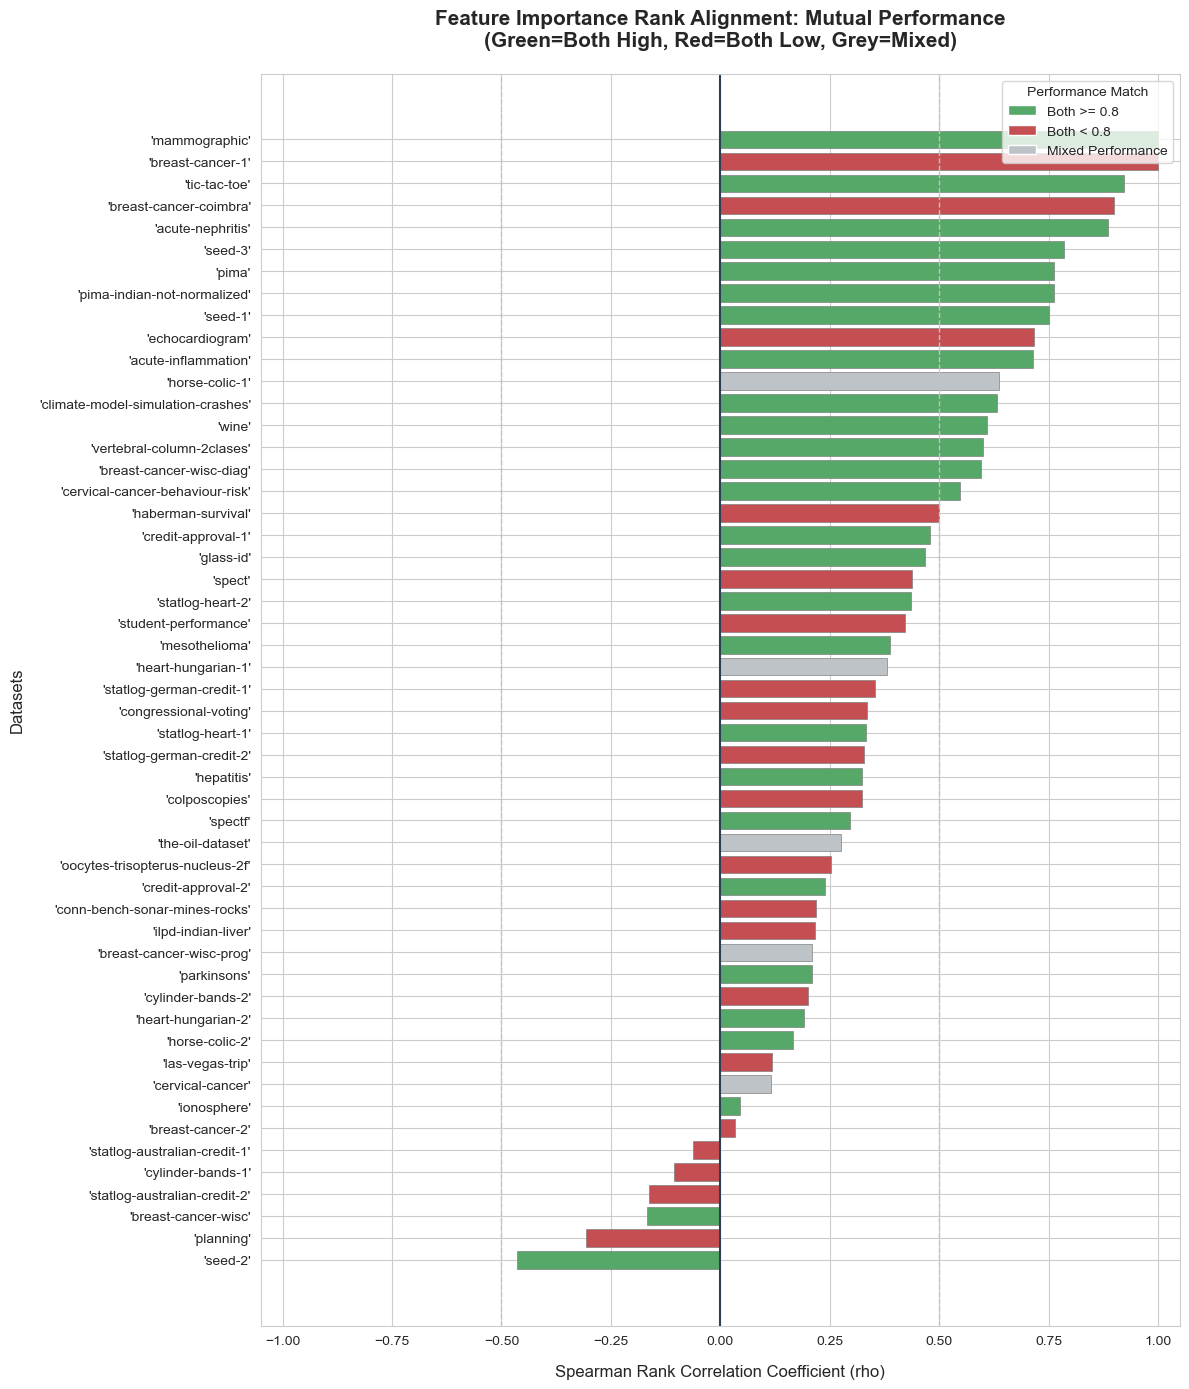

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 1. Prepare data
df_plot = df_analysis.sort_values('Model_Rank_Correlation', ascending=True)

# 2. Define custom color logic
def get_performance_color(row):
    if row['LR ROC-AUC'] >= 0.8 and row['RF ROC-AUC'] >= 0.8:
        return '#55A868' # Both High (Green)
    elif row['LR ROC-AUC'] < 0.8 and row['RF ROC-AUC'] < 0.8:
        return '#C44E52' # Both Low (Red)
    else:
        return '#bdc3c7' # Mixed/Disagree (Grey)

colors = [get_performance_color(row) for _, row in df_plot.iterrows()]

# 3. Create the horizontal bar plot
plt.figure(figsize=(12, 14))
plt.barh(y=df_plot['Dataset'], width=df_plot['Model_Rank_Correlation'], color=colors, edgecolor='grey', linewidth=0.5)

# 4. Guidelines
plt.axvline(x=0, color='#2c3e50', linestyle='-', linewidth=1.5)
plt.axvline(x=0.5, color='#bdc3c7', linestyle='--', linewidth=1)
plt.axvline(x=-0.5, color='#bdc3c7', linestyle='--', linewidth=1)

# 5. Formatting
plt.title("Feature Importance Rank Alignment: Mutual Performance\n(Green=Both High, Red=Both Low, Grey=Mixed)", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Spearman Rank Correlation Coefficient (rho)", fontsize=12, labelpad=12)
plt.ylabel("Datasets", fontsize=12, labelpad=10)
plt.xlim(-1.05, 1.05)

# 6. Add custom legend
legend_elements = [
    Patch(facecolor='#55A868', label='Both >= 0.8'),
    Patch(facecolor='#C44E52', label='Both < 0.8'),
    Patch(facecolor='#bdc3c7', label='Mixed Performance')
]
plt.legend(handles=legend_elements, loc='upper right', title="Performance Match", fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# Count datasets with correlation >= 0.5
high_corr_count = len(df_model_corr[df_model_corr['Model_Rank_Correlation'] >= 0.5])

print(f"Number of datasets with correlation >= 0.5: {high_corr_count}")

# Optional: View the names of those datasets
high_corr_datasets = df_model_corr[df_model_corr['Model_Rank_Correlation'] >= 0.5]['Dataset']
print("\nList of datasets:")
print(high_corr_datasets.tolist())

Number of datasets with correlation >= 0.5: 18

List of datasets:
["'mammographic'", "'breast-cancer-1'", "'tic-tac-toe'", "'breast-cancer-coimbra'", "'acute-nephritis'", "'seed-3'", "'pima'", "'pima-indian-not-normalized'", "'seed-1'", "'echocardiogram'", "'acute-inflammation'", "'horse-colic-1'", "'climate-model-simulation-crashes'", "'wine'", "'vertebral-column-2clases'", "'breast-cancer-wisc-diag'", "'cervical-cancer-behaviour-risk'", "'haberman-survival'"]


In [ ]:
# 1. Create the 3 groups
def categorize_correlation(rho):
    if rho >= 0.5:
        return 'Strong Agreement (>= 0.5)'
    elif rho >= 0:
        return 'Weak Agreement (0 to 0.5)'
    else:
        return 'Negative/Discordant (< 0)'

df_analysis['Correlation_Group'] = df_analysis['Model_Rank_Correlation'].apply(categorize_correlation)

# 2. See the distribution of datasets in these groups
group_counts = df_analysis['Correlation_Group'].value_counts()
print("Number of datasets per category:")
print(group_counts)

# 3. Quick comparison: Average performance by group
summary = df_analysis.groupby('Correlation_Group')[['LR ROC-AUC', 'RF ROC-AUC']].mean()
print("\nAverage Performance by Agreement Group:")
print(summary)

Number of datasets per category:
Correlation_Group
Weak Agreement (0 to 0.5)    28
Strong Agreement (>= 0.5)    18
Negative/Discordant (< 0)     6
Name: count, dtype: int64

Average Performance by Agreement Group:
                           LR ROC-AUC  RF ROC-AUC
Correlation_Group                                
Negative/Discordant (< 0)    0.671088    0.675694
Strong Agreement (>= 0.5)    0.873233    0.868419
Weak Agreement (0 to 0.5)    0.778458    0.788358


In [ ]:
# 1. Merge and build the analysis dataframe
df_analysis = pd.merge(df_lr_results, df_rf_results, on="Dataset")
df_analysis = pd.merge(df_analysis, df_model_corr, on="Dataset")

# 2. Add structural info from your meta_mapping logic
# (Assuming your meta_mapping logic from cell 26 is available or we reconstruct it)
def get_structure_label(row):
    # This matches your logic from your existing notebook
    # We can infer rows/features if you have them, otherwise use the existing groups
    # For this census, let's create flags directly:
    return row['Meta_Group'] 

# 3. Define the 3 buckets (Correlation Groups)
def bucket_corr(rho):
    if rho >= 0.5: return '1. Strong (>=0.5)'
    elif rho >= 0: return '2. Weak (0 to 0.5)'
    else: return '3. Negative (<0)'

df_analysis['Correlation_Bucket'] = df_analysis['Model_Rank_Correlation'].apply(bucket_corr)

# 4. Create binary demographic flags for the "census"
df_analysis['Both >= 0.8'] = (df_analysis['LR ROC-AUC'] >= 0.8) & (df_analysis['RF ROC-AUC'] >= 0.8)
df_analysis['LR >= 0.8']   = df_analysis['LR ROC-AUC'] >= 0.8
df_analysis['RF >= 0.8']   = df_analysis['RF ROC-AUC'] >= 0.8

# Add specific structural flags
df_analysis['Small & Simple'] = df_analysis['Meta_Group'].str.contains('Small & Simple')
df_analysis['Low Row/High Feat'] = df_analysis['Meta_Group'].str.contains('Low Row / High Feat')
df_analysis['High Row/Low Feat'] = df_analysis['Meta_Group'].str.contains('High Row / Low Feat')
df_analysis['Big & Complex'] = df_analysis['Meta_Group'].str.contains('Big & Complex')

# 5. Calculate the "Census" (Percentage of each bucket)
census_cols = ['Both >= 0.8', 'LR >= 0.8', 'RF >= 0.8', 
               'Small & Simple', 'Low Row/High Feat', 'High Row/Low Feat', 'Big & Complex']

census_df = df_analysis.groupby('Correlation_Bucket')[census_cols].mean() * 100

# 6. Display the final census table
print("--- Dataset Census by Correlation Bucket (%) ---")
print(census_df.round(1).to_string())

--- Dataset Census by Correlation Bucket (%) ---
                    Both >= 0.8  LR >= 0.8  RF >= 0.8  Small & Simple  Low Row/High Feat  High Row/Low Feat  Big & Complex
Correlation_Bucket                                                                                                        
1. Strong (>=0.5)          72.2       72.2       77.8            66.7                0.0               22.2           11.1
2. Weak (0 to 0.5)         42.9       53.6       46.4            17.9               46.4               10.7           25.0
3. Negative (<0)           33.3       33.3       33.3            33.3                0.0               50.0           16.7


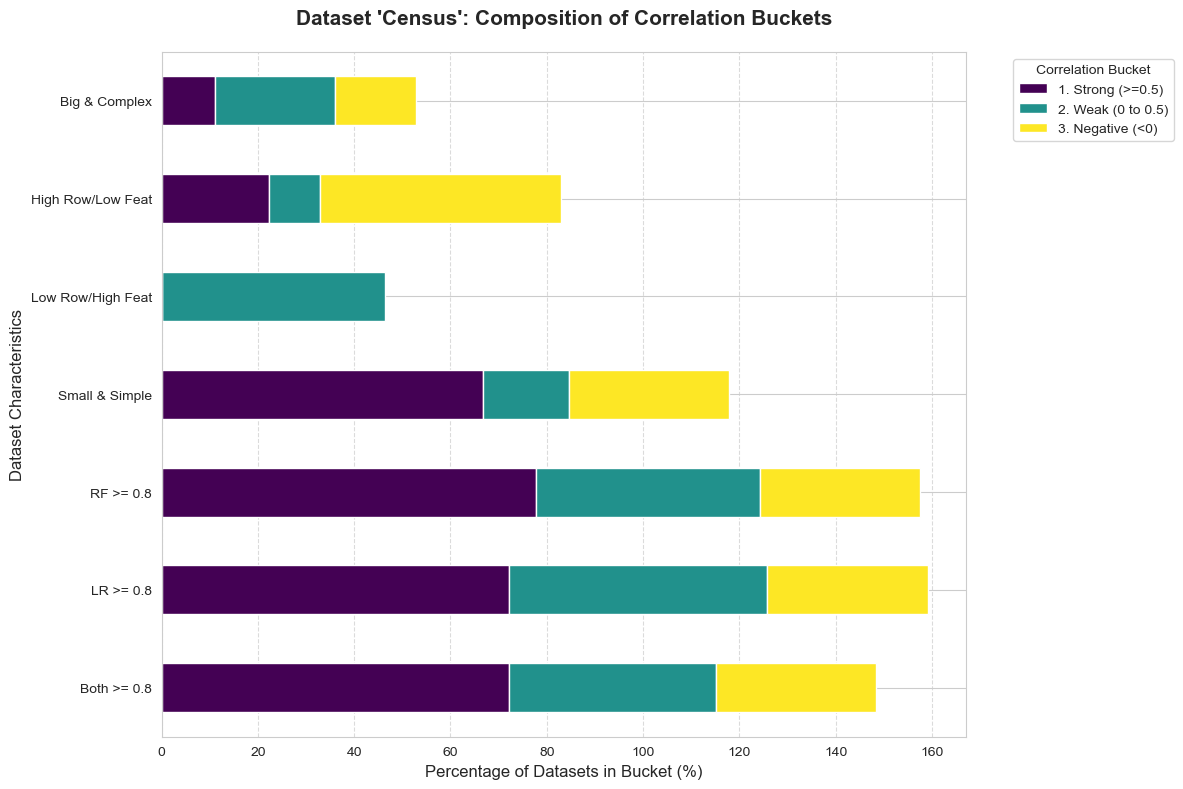

In [ ]:
# 1. Prepare the data: Transpose the census_df so that buckets are columns 
# and characteristics are rows for plotting
plot_df = census_df.T

# 2. Plotting
fig, ax = plt.subplots(figsize=(12, 8))

# We use plot().barh() to create a horizontal stacked bar chart
plot_df.plot(kind='barh', stacked=True, ax=ax, cmap='viridis', edgecolor='white')

# 3. Formatting
plt.title("Dataset 'Census': Composition of Correlation Buckets", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Percentage of Datasets in Bucket (%)", fontsize=12)
plt.ylabel("Dataset Characteristics", fontsize=12)
plt.legend(title="Correlation Bucket", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

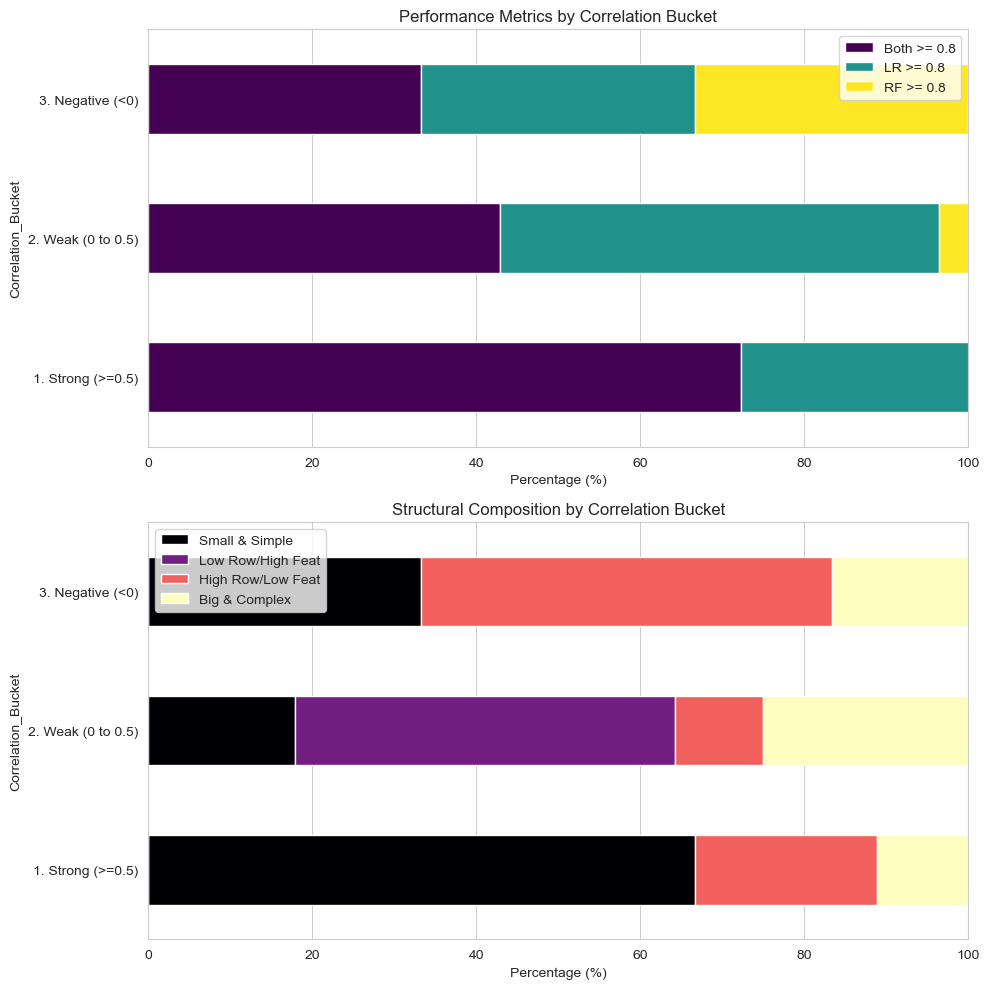

In [ ]:
# 1. Split the data into Performance and Structure
perf_cols = ['Both >= 0.8', 'LR >= 0.8', 'RF >= 0.8']
struct_cols = ['Small & Simple', 'Low Row/High Feat', 'High Row/Low Feat', 'Big & Complex']

# 2. Plot Performance
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

census_df[perf_cols].plot(kind='barh', stacked=True, ax=ax1, cmap='viridis')
ax1.set_title("Performance Metrics by Correlation Bucket")
ax1.set_xlim(0, 100)
ax1.set_xlabel("Percentage (%)")

# 3. Plot Structure
census_df[struct_cols].plot(kind='barh', stacked=True, ax=ax2, cmap='magma')
ax2.set_title("Structural Composition by Correlation Bucket")
ax2.set_xlim(0, 100)
ax2.set_xlabel("Percentage (%)")

plt.tight_layout()
plt.show()

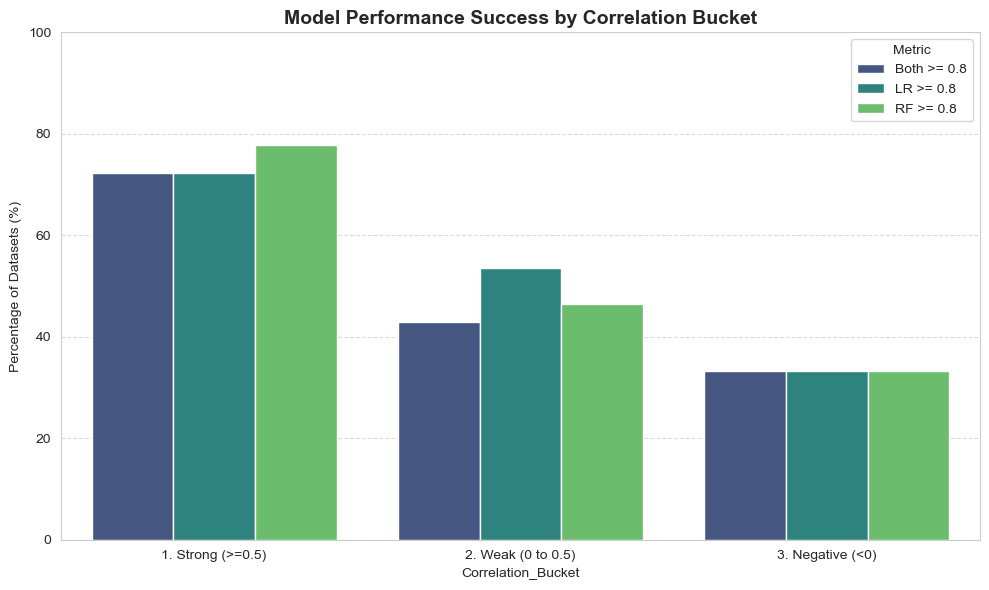

In [ ]:
# Create a side-by-side bar chart
fig, ax = plt.subplots(figsize=(10, 6))

# Melt the dataframe so seaborn can handle the groups easily
perf_melted = df_analysis.melt(id_vars=['Correlation_Bucket'], 
                               value_vars=['Both >= 0.8', 'LR >= 0.8', 'RF >= 0.8'], 
                               var_name='Metric', value_name='Achieved')

# Calculate percentages per group
perf_summary = perf_melted.groupby(['Correlation_Bucket', 'Metric'])['Achieved'].mean().reset_index()
perf_summary['Achieved'] *= 100

# Plot
sns.barplot(data=perf_summary, x='Correlation_Bucket', y='Achieved', hue='Metric', palette='viridis', ax=ax)

# Formatting
ax.set_title("Model Performance Success by Correlation Bucket", fontsize=14, fontweight='bold')
ax.set_ylabel("Percentage of Datasets (%)")
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

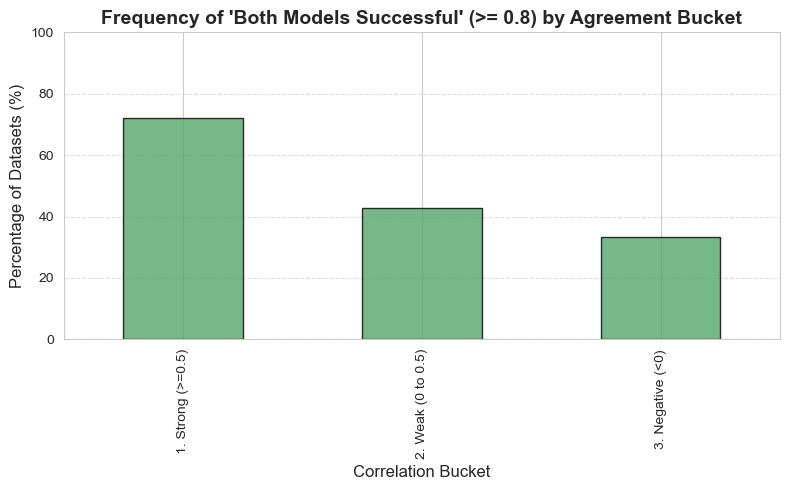

In [ ]:
# 1. Ensure we have the data
# (If you already ran the merge/categorize steps, you can skip to step 2)
if 'df_analysis' not in locals():
    df_analysis = pd.merge(df_lr_results, df_rf_results, on="Dataset")
    df_analysis = pd.merge(df_analysis, df_model_corr, on="Dataset")
    
    def bucket_corr(rho):
        if rho >= 0.5: return '1. Strong (>=0.5)'
        elif rho >= 0: return '2. Weak (0 to 0.5)'
        else: return '3. Negative (<0)'
    df_analysis['Correlation_Bucket'] = df_analysis['Model_Rank_Correlation'].apply(bucket_corr)
    df_analysis['Both >= 0.8'] = (df_analysis['LR ROC-AUC'] >= 0.8) & (df_analysis['RF ROC-AUC'] >= 0.8)

# 2. Calculate the percentage where BOTH are successful
both_success = df_analysis.groupby('Correlation_Bucket')['Both >= 0.8'].mean() * 100

# 3. Plot
plt.figure(figsize=(8, 5))
both_success.plot(kind='bar', color='#55A868', edgecolor='black', alpha=0.8)

plt.title("Frequency of 'Both Models Successful' (>= 0.8) by Agreement Bucket", fontsize=14, fontweight='bold')
plt.ylabel("Percentage of Datasets (%)", fontsize=12)
plt.xlabel("Correlation Bucket", fontsize=12)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# 1. Merge your results if not already done
df_analysis = pd.merge(df_lr_results, df_rf_results, on="Dataset")
df_analysis = pd.merge(df_analysis, df_model_corr, on="Dataset")
df_analysis['Avg ROC-AUC'] = (df_analysis['LR ROC-AUC'] + df_analysis['RF ROC-AUC']) / 2

# 2. Define the 4 Quadrants
def get_behavior_state(row):
    perf = row['Avg ROC-AUC']
    corr = row['Model_Rank_Correlation']
    
    if perf >= 0.8 and corr >= 0.5: return 'High Perf Experts'      # Agreement + Accuracy
    if perf < 0.8 and corr >= 0.5:  return 'Aligned Guessers'       # Agreement + Low Accuracy
    if perf >= 0.8 and corr < 0.5:  return 'Divergent Experts'      # Disagreement + Accuracy
    return 'Total Discord'                                          # Disagreement + Low Accuracy

df_analysis['Behavior_State'] = df_analysis.apply(get_behavior_state, axis=1)

# 3. Add Structural flags for the Census
df_analysis['Rows > 500'] = df_analysis['Rows'] > 500
df_analysis['Features > 25'] = df_analysis['Features'] > 25

# 4. Generate the Census Table
# Compare the percentage makeup of each group
census = df_analysis.groupby('Behavior_State')[['Rows > 500', 'Features > 25']].mean() * 100

print("--- Census: Makeup of Model Behaviors (%) ---")
print(census.round(1).to_string())

--- Census: Makeup of Model Behaviors (%) ---
                   Rows > 500  Features > 25
Behavior_State                              
Aligned Guessers          0.0            0.0
Divergent Experts        26.7           53.3
High Perf Experts        46.2           15.4
Total Discord            52.6           52.6


In [ ]:
# 1. Ensure all DataFrames are merged (if not already done)
# We assume df_lr_results, df_rf_results, df_model_corr, and all_datasets are in your memory
df_analysis = pd.merge(df_lr_results, df_rf_results, on="Dataset")
df_analysis = pd.merge(df_analysis, df_model_corr, on="Dataset")

# 2. Add Structure Groups
meta_mapping = []
for name, dataset_content in all_datasets.items():
    r = dataset_content['X'].shape[0]
    f = dataset_content['X'].shape[1]
    if r <= 500 and f <= 20: grp = "Small & Simple"
    elif r <= 500 and f > 20: grp = "Low Row / High Feat"
    elif r > 500 and f <= 20: grp = "High Row / Low Feat"
    else: grp = "Big & Complex"
    meta_mapping.append({"Dataset": name, "Structure_Group": grp})

df_meta = pd.DataFrame(meta_mapping)
df_analysis = pd.merge(df_analysis, df_meta, on="Dataset")

# 3. Categorize Correlation
def categorize_correlation(rho):
    if rho >= 0.5: return 'Strong'
    elif rho >= 0: return 'Weak'
    else: return 'Negative'

df_analysis['Correlation_Group'] = df_analysis['Model_Rank_Correlation'].apply(categorize_correlation)

# 4. Create Performance Bins
def get_perf_bin(score):
    if score >= 0.8: return 'High'
    elif score >= 0.5: return 'Medium'
    else: return 'Low'

df_analysis['LR_Bin'] = df_analysis['LR ROC-AUC'].apply(get_perf_bin)
df_analysis['RF_Bin'] = df_analysis['RF ROC-AUC'].apply(get_perf_bin)

# 5. Build the Summary Table
struct_cols = ['Small & Simple', 'Low Row / High Feat', 'High Row / Low Feat', 'Big & Complex']
corr_cols = ['Strong', 'Weak', 'Negative']

results = []
for model in ['LR', 'RF']:
    for bin_val in ['High', 'Medium', 'Low']:
        subset = df_analysis[df_analysis[f'{model}_Bin'] == bin_val]
        row = {'Group': f'{model}_{bin_val}'}
        
        # Calculate structure percentages
        for s in struct_cols:
            row[s] = (subset['Structure_Group'] == s).mean() * 100
        # Calculate correlation percentages
        for c in corr_cols:
            row[c] = (subset['Correlation_Group'] == c).mean() * 100
        
        results.append(row)

df_final_table = pd.DataFrame(results)
print(df_final_table.to_string(index=False))

    Group  Small & Simple  Low Row / High Feat  High Row / Low Feat  Big & Complex    Strong      Weak   Negative
  LR_High       40.000000            26.666667            20.000000      13.333333 43.333333 50.000000   6.666667
LR_Medium       31.578947            26.315789            15.789474      26.315789 26.315789 63.157895  10.526316
   LR_Low       33.333333             0.000000            33.333333      33.333333  0.000000 33.333333  66.666667
  RF_High       41.379310            24.137931            20.689655      13.793103 48.275862 44.827586   6.896552
RF_Medium       27.272727            27.272727            18.181818      27.272727 18.181818 68.181818  13.636364
   RF_Low      100.000000             0.000000             0.000000       0.000000  0.000000  0.000000 100.000000


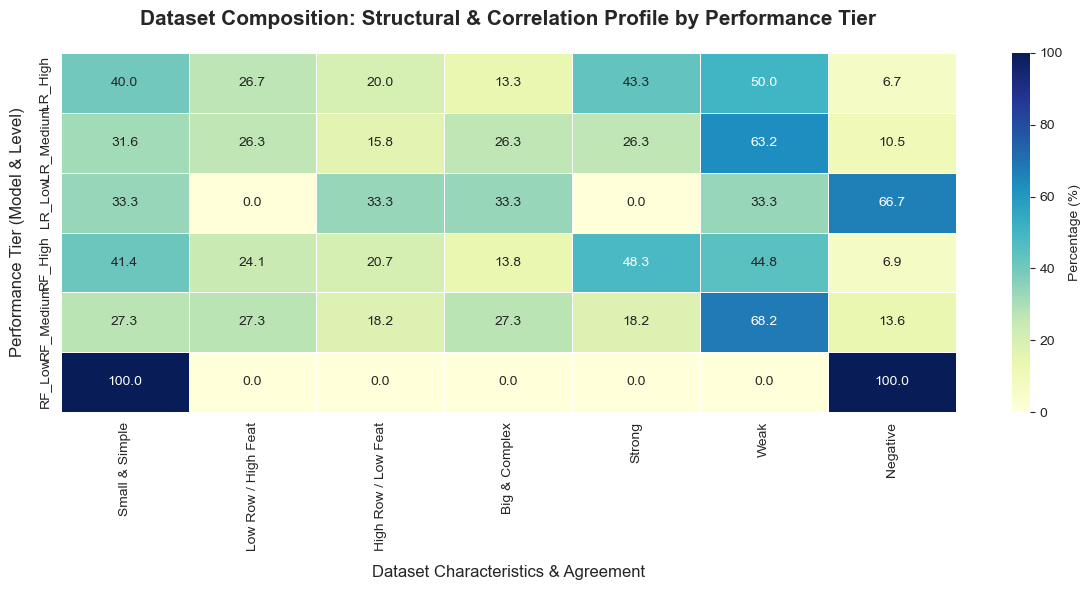

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare the DataFrame for plotting
# Set 'Group' as index so it labels the rows
plot_df = df_final_table.set_index('Group')

# 2. Setup the figure
plt.figure(figsize=(12, 6))

# 3. Create Heatmap
# Using a 'coolwarm' or 'viridis' palette helps distinguish intensities
sns.heatmap(plot_df, annot=True, cmap="YlGnBu", fmt=".1f", linewidths=.5, cbar_kws={'label': 'Percentage (%)'})

# 4. Styling
plt.title("Dataset Composition: Structural & Correlation Profile by Performance Tier", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Dataset Characteristics & Agreement", fontsize=12, labelpad=10)
plt.ylabel("Performance Tier (Model & Level)", fontsize=12, labelpad=10)
plt.tight_layout()

plt.show()

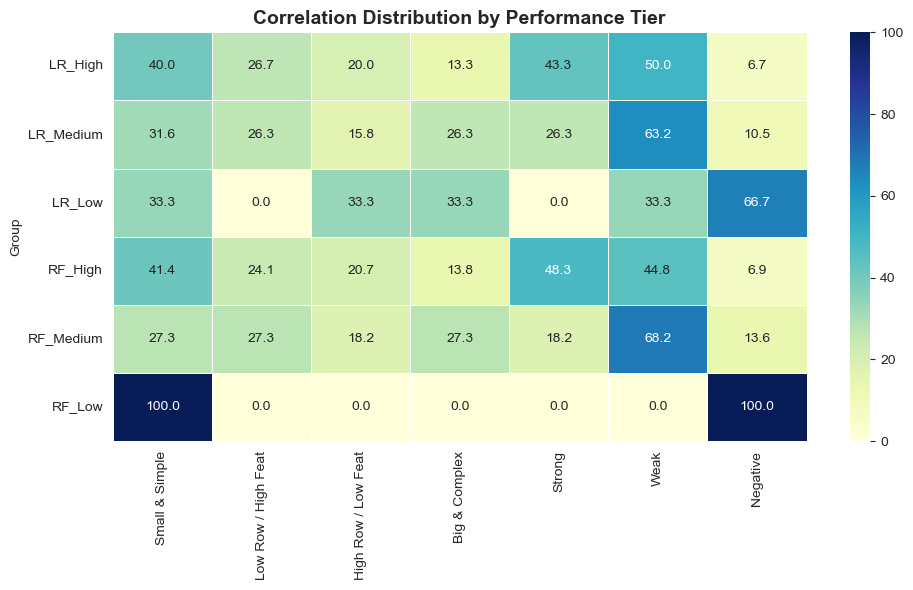

In [ ]:
# Create the heatmap
plt.figure(figsize=(10, 6))
ax = sns.heatmap(plot_df, annot=True, cmap="YlGnBu", fmt=".1f", linewidths=.5)

# Rotate y-labels to be horizontal (easier to read)
plt.yticks(rotation=0) 

plt.title("Correlation Distribution by Performance Tier", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap', dpi=300, bbox_inches='tight')
plt.show()

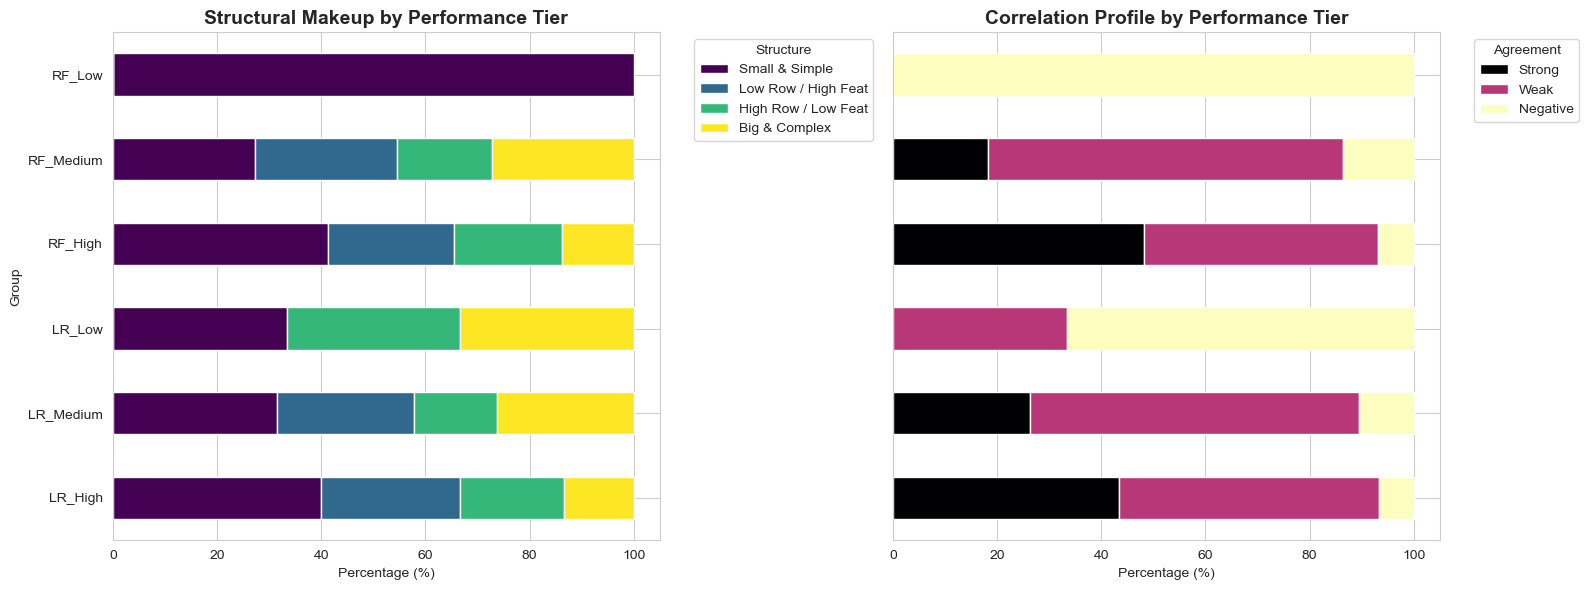

In [ ]:
# 1. Define the two categories
struct_cols = ['Small & Simple', 'Low Row / High Feat', 'High Row / Low Feat', 'Big & Complex']
corr_cols = ['Strong', 'Weak', 'Negative']

# 2. Setup a figure with 2 subplots (side-by-side)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# 3. Plot Structural Composition
df_final_table.set_index('Group')[struct_cols].plot(kind='barh', stacked=True, ax=ax1, colormap='viridis', edgecolor='white')
ax1.set_title("Structural Makeup by Performance Tier", fontsize=14, fontweight='bold')
ax1.set_xlabel("Percentage (%)")
ax1.legend(title="Structure", bbox_to_anchor=(1.05, 1), loc='upper left')

# 4. Plot Correlation Profile
df_final_table.set_index('Group')[corr_cols].plot(kind='barh', stacked=True, ax=ax2, colormap='magma', edgecolor='white')
ax2.set_title("Correlation Profile by Performance Tier", fontsize=14, fontweight='bold')
ax2.set_xlabel("Percentage (%)")
ax2.legend(title="Agreement", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('final', dpi=300, bbox_inches='tight')
plt.show()

### To evaluate the relationship between predictive performance and model interpretability, I organized the 52 datasets into a 3x3 matrix